In [ ]:
pip install pandas numpy matplotlib seaborn statsmodels xgboost scikit-learn scipy

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")
df.head()


,Date,District,Dengue_Cases,Temperature,Humidity,Rainfall_mm
0,1/1/2020,Dhaka,9,20.1,70,0.0
1,1/2/2020,Dhaka,10,21.7,73,0.0
2,1/3/2020,Dhaka,17,18.7,89,2.0
3,1/4/2020,Dhaka,22,19.2,84,18.0
4,1/5/2020,Dhaka,20,18.8,82,0.0


In [ ]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Load data
# --------------------------------------------------
df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")

# --------------------------------------------------
# 2. Define correct column names
# --------------------------------------------------
variables = {
    "Dengue Cases (overall period)": "Dengue_Cases",
    "Temperature (°C)": "Temperature",
    "Humidity (%)": "Humidity",
    "Rainfall (mm)": "Rainfall_mm"
}

# --------------------------------------------------
# 3. Compute descriptive statistics
# --------------------------------------------------
rows = []

for label, col in variables.items():
    if col not in df.columns:
        print(f"⚠ Column '{col}' not found — skipped")
        continue

    s = pd.to_numeric(df[col], errors="coerce").dropna()

    rows.append({
        "Characteristic": label,
        "Minimum": s.min(),
        "Maximum": s.max(),
        "Average (SD)": (
            f"{s.mean():,.0f} ({s.std():,.0f})"
            if "Dengue" in label
            else f"{s.mean():.2f} ({s.std():.2f})"
        ),
        "Skewness": s.skew(),
        "Kurtosis": s.kurt(),   # excess kurtosis
        "Median": s.median()
    })

desc_table = pd.DataFrame(rows)

# --------------------------------------------------
# 4. Formatting (paper-ready)
# --------------------------------------------------
desc_table["Minimum"] = desc_table["Minimum"].apply(
    lambda x: f"{x:,.0f}" if x >= 1000 else f"{x:.2f}"
)
desc_table["Maximum"] = desc_table["Maximum"].apply(
    lambda x: f"{x:,.0f}" if x >= 1000 else f"{x:.2f}"
)
desc_table["Skewness"] = desc_table["Skewness"].apply(lambda x: f"{x:.2f}")
desc_table["Kurtosis"] = desc_table["Kurtosis"].apply(lambda x: f"{x:.2f}")
desc_table["Median"] = desc_table["Median"].apply(
    lambda x: f"{x:,.0f}" if x >= 1000 else f"{x:.2f}"
)

desc_table = desc_table[
    ["Characteristic", "Minimum", "Maximum", "Average (SD)", "Skewness", "Kurtosis", "Median"]
]

# --------------------------------------------------
# 5. Display output
# --------------------------------------------------
print("\nTable 1. Descriptive statistics of dengue cases and meteorological factors\n")
print(desc_table.to_string(index=False))



Table 1. Descriptive statistics of dengue cases and meteorological factors

               Characteristic Minimum Maximum  Average (SD) Skewness Kurtosis Median
Dengue Cases (overall period)    0.00   1,327     152 (227)     2.12     4.78  41.00
             Temperature (°C)   13.30   34.00  26.42 (4.19)    -0.73    -0.48  27.70
                 Humidity (%)   32.00   98.00 72.31 (10.83)    -0.45     0.17  73.00
                Rainfall (mm)    0.00  265.00  6.86 (21.36)     6.13    50.63   0.00


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# --------------------------------------------------
# 1. Load data
# --------------------------------------------------
df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")

# --------------------------------------------------
# 2. Define variables
# --------------------------------------------------
variables = {
    "Dengue Cases":      "Dengue_Cases",
    "Temperature (°C)":  "Temperature",
    "Humidity (%)":      "Humidity",
    "Rainfall (mm)":     "Rainfall_mm"
}

# --------------------------------------------------
# 3. Normality test + full descriptive stats
# --------------------------------------------------
rows = []

for label, col in variables.items():
    if col not in df.columns:
        print(f"⚠ Column '{col}' not found — skipped")
        continue

    s = pd.to_numeric(df[col], errors="coerce").dropna()

    # Normality — Shapiro-Wilk (use on sample ≤5000)
    # For large N use D'Agostino-Pearson K² test
    if len(s) <= 5000:
        stat, p_norm = stats.shapiro(s)
        test_used = "Shapiro-Wilk"
    else:
        stat, p_norm = stats.normaltest(s)   # D'Agostino-Pearson
        test_used = "D'Agostino-Pearson"

    is_normal = p_norm > 0.05   # True = normally distributed

    # Core stats
    mean_val   = s.mean()
    sd_val     = s.std()
    median_val = s.median()
    q1         = s.quantile(0.25)
    q3         = s.quantile(0.75)
    iqr_val    = q3 - q1
    skew_val   = s.skew()
    kurt_val   = s.kurt()
    min_val    = s.min()
    max_val    = s.max()
    n          = len(s)

    # Format helpers
    def fmt(v, is_dengue):
        return f"{v:,.0f}" if is_dengue else f"{v:.2f}"

    is_dengue = "Dengue" in label

    rows.append({
        "Variable":            label,
        "N":                   n,
        "Min":                 fmt(min_val, is_dengue),
        "Max":                 fmt(max_val, is_dengue),
        "Mean (SD)":           (f"{mean_val:,.0f} ({sd_val:,.0f})"
                                if is_dengue
                                else f"{mean_val:.2f} ({sd_val:.2f})"),
        "Median [Q1–Q3]":      (f"{median_val:,.0f} [{q1:,.0f}–{q3:,.0f}]"
                                if is_dengue
                                else f"{median_val:.2f} [{q1:.2f}–{q3:.2f}]"),
        "IQR":                 fmt(iqr_val, is_dengue),
        "Skewness":            f"{skew_val:.2f}",
        "Kurtosis":            f"{kurt_val:.2f}",
        "Normality test":      test_used,
        "p (normality)":       f"{p_norm:.4f}",
        "Distribution":        "Normal ✓" if is_normal else "Non-normal ✗",
        "Report as":           "Mean (SD)" if is_normal else "Median [IQR]",
    })

desc_df = pd.DataFrame(rows)

# --------------------------------------------------
# 4. Print full table
# --------------------------------------------------
print("=" * 80)
print("Table 1. Descriptive Statistics — Dengue Cases & Meteorological Variables")
print("         Dhaka, Bangladesh (2020–2024)")
print("=" * 80)

display_cols = [
    "Variable", "N", "Min", "Max",
    "Mean (SD)", "Median [Q1–Q3]", "IQR",
    "Skewness", "Kurtosis", "Distribution", "Report as"
]
print(desc_df[display_cols].to_string(index=False))

# --------------------------------------------------
# 5. Normality summary — tells you exactly what to
#    report in the paper per Assel et al. (2018)
# --------------------------------------------------
print("\n" + "=" * 80)
print("REPORTING GUIDE — Assel et al. (2018) compliance")
print("=" * 80)
for _, row in desc_df.iterrows():
    print(f"\n  {row['Variable']}")
    print(f"    Distribution : {row['Distribution']}  "
          f"(p={row['p (normality)']}  by {row['Normality test']})")
    print(f"    → Report as  : {row['Report as']}")
    if "Non-normal" in row["Distribution"]:
        print(f"    → Use        : Median [Q1–Q3]  =  {row['Median [Q1–Q3]']}  "
              f"(IQR = {row['IQR']})")
    else:
        print(f"    → Use        : Mean (SD)  =  {row['Mean (SD)']}")

# --------------------------------------------------
# 6. Save to CSV
# --------------------------------------------------
desc_df.to_csv("Table1_Descriptive_Statistics_With_IQR.csv", index=False)
print("\n\nSaved: Table1_Descriptive_Statistics_With_IQR.csv")

Table 1. Descriptive Statistics — Dengue Cases & Meteorological Variables
         Dhaka, Bangladesh (2020–2024)
        Variable    N   Min    Max     Mean (SD)      Median [Q1–Q3]   IQR Skewness Kurtosis Distribution    Report as
    Dengue Cases 1826     0  1,327     152 (227)          41 [6–220]   214     2.12     4.78 Non-normal ✗ Median [IQR]
Temperature (°C) 1826 13.30  34.00  26.42 (4.19) 27.70 [23.31–29.70]  6.39    -0.73    -0.48 Non-normal ✗ Median [IQR]
    Humidity (%) 1826 32.00  98.00 72.31 (10.83) 73.00 [66.00–80.00] 14.00    -0.45     0.17 Non-normal ✗ Median [IQR]
   Rainfall (mm) 1826  0.00 265.00  6.86 (21.36)    0.00 [0.00–2.00]  2.00     6.13    50.63 Non-normal ✗ Median [IQR]

REPORTING GUIDE — Assel et al. (2018) compliance

  Dengue Cases
    Distribution : Non-normal ✗  (p=0.0000  by Shapiro-Wilk)
    → Report as  : Median [IQR]
    → Use        : Median [Q1–Q3]  =  41 [6–220]  (IQR = 214)

  Temperature (°C)
    Distribution : Non-normal ✗  (p=0.0000  by Shap

In [ ]:
from statsmodels.tsa.stattools import adfuller

y = df['Dengue_Cases']

# Run Augmented Dickey-Fuller test
adf_result = adfuller(y)

# Print results
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for k, v in adf_result[4].items():
    print(f"  {k}: {v}")



ADF Statistic: -2.979227534329042
p-value: 0.036880352494986994
Critical Values:
  1%: -3.4339881389288407
  5%: -2.863147035877915
  10%: -2.567625533641975


In [ ]:
df.columns

Index(['Date', 'District', 'Dengue_Cases', 'Temperature', 'Humidity',
       'Rainfall_mm'],
      dtype='object')

Files saved as:
Daily_Dengue_TimeSeries_2020_2024.png
Daily_Dengue_TimeSeries_2020_2024.pdf


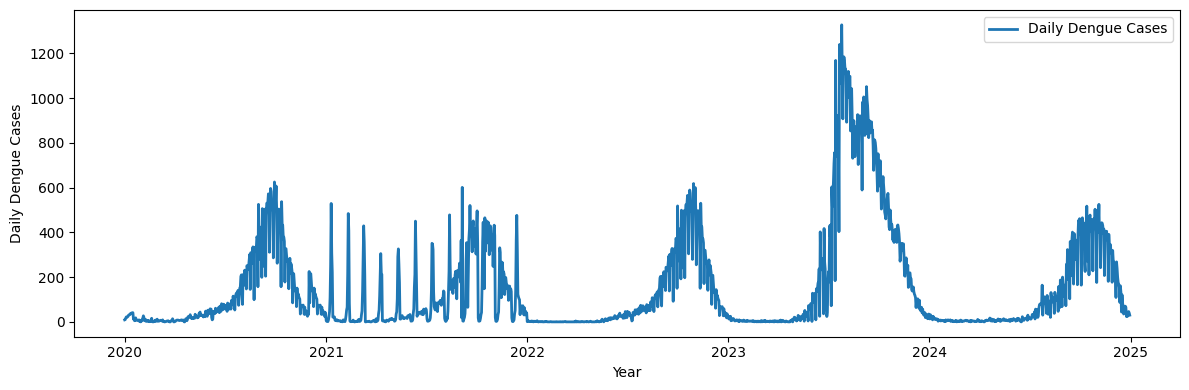

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --------------------------------------------------
# 1) Load Dataset
# --------------------------------------------------
file_path = "/content/dhaka_dengue_weather_2020_2024.csv"
df = pd.read_csv(file_path)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

y = df["Dengue_Cases"]

# --------------------------------------------------
# 2) Plot
# --------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(y.index, y.values, linewidth=2, label="Daily Dengue Cases")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xlabel("Year")
plt.ylabel("Daily Dengue Cases")
plt.legend()
plt.tight_layout()

# --------------------------------------------------
# 3) Save Files (PNG + PDF)
# --------------------------------------------------
png_filename = "Daily_Dengue_TimeSeries_2020_2024.png"
pdf_filename = "Daily_Dengue_TimeSeries_2020_2024.pdf"

#plt.savefig(png_filename, dpi=600, bbox_inches="tight")
#plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")

print(f"Files saved as:\n{png_filename}\n{pdf_filename}")

# --------------------------------------------------
# 4) Show Plot
# --------------------------------------------------
plt.show()


Heatmap saved as:
Dhaka_Dengue_Heatmap_2020_2024.png
Dhaka_Dengue_Heatmap_2020_2024.pdf


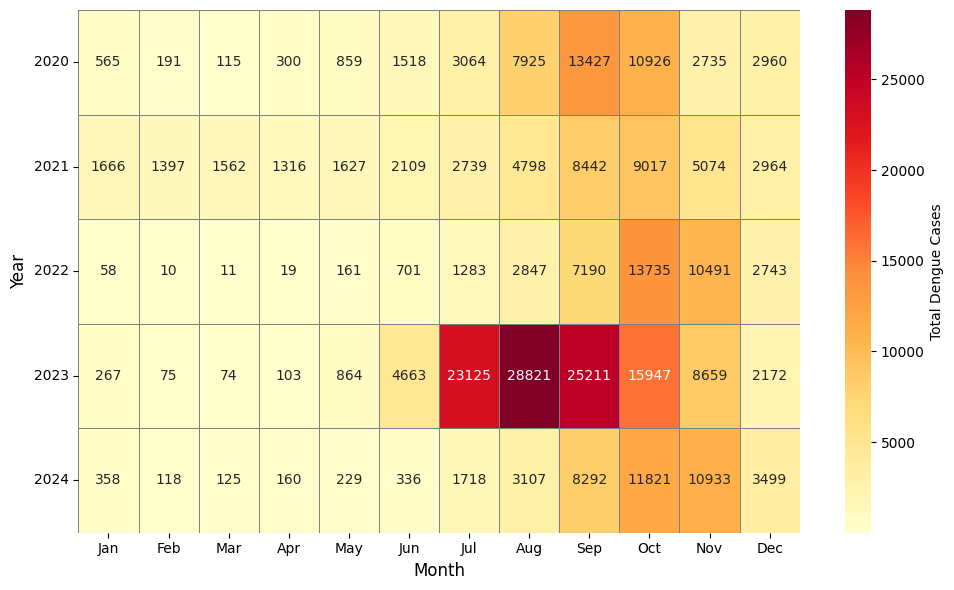

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ────────────────────────────────────────────────
# 1) Load and prepare data
# ────────────────────────────────────────────────
file_path = "/content/dhaka_dengue_weather_2020_2024.csv"
df = pd.read_csv(file_path)

# Make sure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extract year and month
df["Year"]  = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")  # Jan, Feb, ..., Dec

# Aggregate dengue cases by Year-Month
monthly_cases = df.groupby(["Year", "Month", "Month_Name"])["Dengue_Cases"].sum().reset_index()

# ────────────────────────────────────────────────
# 2) Create pivot table for heatmap
#    rows = years, columns = months
# ────────────────────────────────────────────────
pivot = monthly_cases.pivot(
    index="Year",
    columns="Month",
    values="Dengue_Cases"
)

# Optional: fill missing months with 0 (if any month has no cases recorded)
pivot = pivot.fillna(0)

# To use month names instead of numbers on x-axis
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
pivot.columns = month_names

# ────────────────────────────────────────────────
# 3) Create the heatmap
# ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,                # show numbers in cells
    fmt=".0f",                 # no decimal places
    cmap="YlOrRd",             # yellow → orange → red (good for cases)
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Total Dengue Cases"},
)

# Titles and labels
#plt.title("Dhaka Dengue Cases Heatmap (2020–2024)\nTotal Cases per Month", fontsize=14, pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Year", fontsize=12)

# Make sure years are shown as integers (not floats)
plt.yticks(rotation=0)

plt.tight_layout()

# ────────────────────────────────────────────────
# 4) Save high-quality versions
# ────────────────────────────────────────────────
png_filename = "Dhaka_Dengue_Heatmap_2020_2024.png"
pdf_filename = "Dhaka_Dengue_Heatmap_2020_2024.pdf"

#plt.savefig(png_filename, dpi=600, bbox_inches="tight")
#plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")

print(f"Heatmap saved as:\n{png_filename}\n{pdf_filename}")

# Show the plot
plt.show()

**For Download**

In [ ]:
!ls /content

Daily_Dengue_TimeSeries_2020_2024.pdf  dhaka_dengue_weather_2020_2024.csv
Daily_Dengue_TimeSeries_2020_2024.png  sample_data


In [ ]:
df.columns

Index(['Date', 'District', 'Dengue_Cases', 'Temperature', 'Humidity',
       'Rainfall_mm', 'Year', 'Month', 'Month_Name'],
      dtype='object')

In [ ]:
vars_for_corr = df[["Dengue_Cases", "Temperature","Humidity", "Rainfall_mm"]]


**Spearman Correlation**

In [ ]:
spearman_corr = vars_for_corr.corr(method="spearman")
spearman_corr

,Dengue_Cases,Temperature,Humidity,Rainfall_mm
Dengue_Cases,1.000000,0.244117,0.377296,0.167529
Temperature,0.244117,1.000000,0.138269,0.218686
Humidity,0.377296,0.138269,1.000000,0.456304
Rainfall_mm,0.167529,0.218686,0.456304,1.000000


**P-Value**

In [ ]:
from scipy.stats import spearmanr

rho, pval = spearmanr(vars_for_corr, nan_policy="omit")
p_values = pd.DataFrame(
    pval,
    index=vars_for_corr.columns,
    columns=vars_for_corr.columns
)

p_values

,Dengue_Cases,Temperature,Humidity,Rainfall_mm
Dengue_Cases,0.000000e+00,3.500530e-26,7.428482e-63,5.809551e-13
Temperature,3.500530e-26,0.000000e+00,2.975429e-09,3.290658e-21
Humidity,7.428482e-63,2.975429e-09,0.000000e+00,1.386879e-94
Rainfall_mm,5.809551e-13,3.290658e-21,1.386879e-94,0.000000e+00


**1.Standard Spearman Correlation Matrix (Same-Time Correlation)**

The standard Spearman correlation matrix represents the strength and direction of association between variables measured at the same time point. In this matrix, each variable is correlated with every other variable in the dataset without considering any temporal delay. Because each variable is perfectly correlated with itself, the diagonal elements of the matrix are equal to 1.00. This type of correlation matrix is commonly used for exploratory data analysis, allowing researchers to assess overall relationships and detect potential multicollinearity among predictors. For example, the correlation between dengue cases and humidity in the same time period reflects how strongly they vary together concurrently. However, for infectious diseases such as dengue, same-time correlations may underestimate the true environmental influence, as climatic factors often affect transmission dynamics after a delay rather than instantaneously.

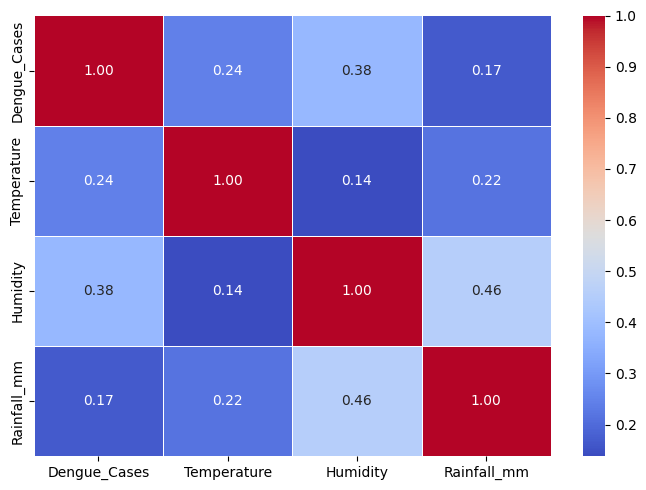

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

# Choose variables (no lags here)
vars_for_corr = ["Dengue_Cases", "Temperature", "Humidity", "Rainfall_mm"]

corr_matrix = df[vars_for_corr].corr(method="spearman")

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
#plt.title("Spearman Correlation Matrix")

#plt.savefig("spearman_correlation_dhaka_dengue_weather.png", dpi=600, bbox_inches="tight")
#plt.savefig("spearman_correlation_dhaka_dengue_weather.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()


**Lag Feature Engineering for Dengue Forecasting**

To capture the delayed effects of both past dengue cases and climatic factors, lagged features were created using the .shift() function. For dengue cases, autoregressive lags of 7, 14, 21, and 30 days were generated to represent short-term temporal dependence, reflecting weekly transmission cycles and reporting patterns. These variables allow the model to incorporate recent historical trends in dengue incidence.

In addition, lagged climate variables (temperature, humidity, and rainfall) were created at 7, 14, 30, 45, and 60 days to account for the delayed biological impact of environmental conditions on mosquito breeding and virus transmission. Since climatic factors influence dengue transmission indirectly—through mosquito development, virus incubation, and human infection cycles—these delays typically range from two to eight weeks.

By adding these lagged variables, the time-series problem is transformed into a supervised machine learning framework, where the model predicts current dengue cases using both past dengue values and prior climatic conditions. Rows with missing values resulting from lag creation were removed before model training to ensure data integrity.

In [ ]:
# Dengue autoregressive lags
for lag in [7, 14, 21, 30]:
    df[f"Dengue_Lag{lag}"] = df["Dengue_Cases"].shift(lag)

# Climate lags
for lag in [7, 14, 30, 45, 60]:
    df[f"Humidity_Lag{lag}"] = df["Humidity"].shift(lag)
    df[f"Rainfall_Lag{lag}"] = df["Rainfall_mm"].shift(lag)
    df[f"Temperature_Lag{lag}"] = df["Temperature"].shift(lag)



In [ ]:
lag_days = [7, 14, 30, 45, 60]

results = []

for lag in lag_days:
    cols = [
        "Dengue_Cases",
        f"Temperature_Lag{lag}",
        f"Humidity_Lag{lag}",
        f"Rainfall_Lag{lag}"
    ]

    temp_df = df[cols].dropna()
    corr = temp_df.corr(method="spearman").iloc[0, 1:]

    results.append({
        "Lag (Days)": lag,
        "Temp Corr": corr[0],
        "Humidity Corr": corr[1],
        "Rainfall Corr": corr[2]
    })

corr_table = pd.DataFrame(results)
corr_table


/tmp/ipykernel_2411/1680812217.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Temp Corr": corr[0],
/tmp/ipykernel_2411/1680812217.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Humidity Corr": corr[1],
/tmp/ipykernel_2411/1680812217.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Rainfall Corr": corr[2]
/tmp/ipykernel_2411/1680812217.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecate

,Lag (Days),Temp Corr,Humidity Corr,Rainfall Corr
0,7,0.319226,0.402329,0.241161
1,14,0.405338,0.405750,0.276063
2,30,0.533092,0.447074,0.342544
3,45,0.632078,0.433502,0.395267
4,60,0.691739,0.411139,0.399065


**P Value For Lagged Features**

In [ ]:
from scipy.stats import spearmanr
import pandas as pd

lag_days = [7, 14, 30, 45, 60]
p_results = []

for lag in lag_days:

    cols = [
        "Dengue_Cases",
        f"Temperature_Lag{lag}",
        f"Humidity_Lag{lag}",
        f"Rainfall_Lag{lag}"
    ]

    temp_df = df[cols].dropna()

    # Extract only p-values (second output from spearmanr)
    _, temp_p = spearmanr(temp_df["Dengue_Cases"],
                          temp_df[f"Temperature_Lag{lag}"])

    _, hum_p = spearmanr(temp_df["Dengue_Cases"],
                         temp_df[f"Humidity_Lag{lag}"])

    _, rain_p = spearmanr(temp_df["Dengue_Cases"],
                          temp_df[f"Rainfall_Lag{lag}"])

    p_results.append({
        "Lag (Days)": lag,
        "Temp p-value": temp_p,
        "Humidity p-value": hum_p,
        "Rainfall p-value": rain_p
    })

p_table = pd.DataFrame(p_results)
p_table


,Lag (Days),Temp p-value,Humidity p-value,Rainfall p-value
0,7,2.286666e-44,9.897829e-72,1.757309e-25
1,14,1.318537e-72,9.175393e-73,4.706880e-33
2,30,2.007118e-132,5.705040e-89,1.308076e-50
3,45,2.807668e-199,1.679137e-82,1.127604e-67
4,60,1.135314e-251,5.436477e-73,1.702332e-68


**2.Lagged Spearman Correlation Heatmap (Delayed Effect Analysis**

The lagged Spearman correlation heatmap evaluates the relationship between current dengue cases and climate variables measured at earlier time points. Instead of correlating variables measured simultaneously, this approach incorporates biologically meaningful time delays (lags) such as 7, 14, 30, 45, and 60 days. This structure does not produce a square matrix and does not contain diagonal values of 1 because the analysis does not compare a variable with itself. Rather, it examines whether past climatic conditions influence present dengue incidence. This method is particularly important for vector-borne diseases, as mosquito breeding cycles, viral incubation periods, and environmental responses occur over time. The lagged heatmap therefore provides deeper epidemiological insight and is especially useful for identifying optimal lag periods for predictive modeling and forecasting.

Heatmap saved successfully.


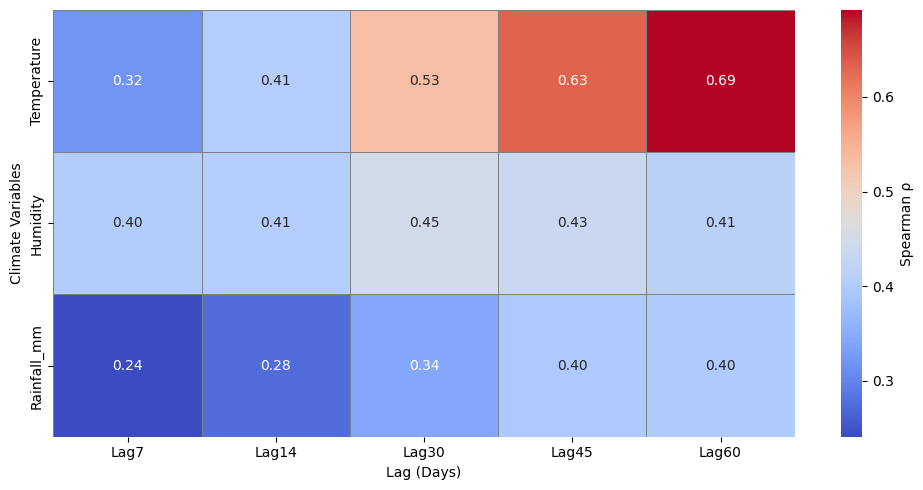

In [ ]:
# ==========================================================
#    Dengue Cases vs Climate Variables
# ==========================================================

# ----------------------------------------------------------
# 1) Import Libraries
# ----------------------------------------------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 2) Load Dataset (Daily)
# ----------------------------------------------------------
df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

# ----------------------------------------------------------
# 3) Define Biologically Meaningful Lags (Days)
# ----------------------------------------------------------
lag_days = [7, 14, 30, 45, 60]
climate_vars = ["Temperature", "Humidity", "Rainfall_mm"]

# ----------------------------------------------------------
# 4) Create Lagged Climate Variables
# ----------------------------------------------------------
for lag in lag_days:
    for var in climate_vars:
        df[f"{var}_Lag{lag}"] = df[var].shift(lag)

# ----------------------------------------------------------
# 5) Compute Spearman Correlation Matrix
#    Rows   = Climate Variables
#    Columns= Lag Days
# ----------------------------------------------------------
lag_corr = pd.DataFrame(
    index=climate_vars,
    columns=[f"Lag{d}" for d in lag_days],
    dtype=float
)

for var in climate_vars:
    for lag in lag_days:
        temp_df = df[["Dengue_Cases", f"{var}_Lag{lag}"]].dropna()
        lag_corr.loc[var, f"Lag{lag}"] = temp_df["Dengue_Cases"].corr(
            temp_df[f"{var}_Lag{lag}"],
            method="spearman"
        )

# ----------------------------------------------------------
# 6) Plot Heatmap
# ----------------------------------------------------------
plt.figure(figsize=(10, 5))

sns.heatmap(
    lag_corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="gray",
    fmt=".2f",
    cbar_kws={"label": "Spearman ρ"}
)

plt.xlabel("Lag (Days)")
plt.ylabel("Climate Variables")
#plt.title("Lagged Spearman Correlation Heatmap\n(Daily Dengue vs Climate Variables)")
plt.tight_layout()

# ----------------------------------------------------------
# 7) Save Files
# ----------------------------------------------------------
#plt.savefig("Lagged_Spearman_Correlation_Heatmap_Daily.png", dpi=600, bbox_inches="tight")
#plt.savefig("Lagged_Spearman_Correlation_Heatmap_Daily.pdf", format="pdf", bbox_inches="tight")

print("Heatmap saved successfully.")

plt.show()


**Selection of Optimal Lag Periods Based on Spearman Correlation**

Selection of Optimal Lag Periods Based on Spearman Correlation

To identify the most influential delayed effects of climatic variables on dengue incidence, Spearman rank correlation analysis was conducted using multiple lag periods (7, 14, 30, 45, and 60 days). The results indicate that temperature shows a progressively increasing correlation with dengue cases, reaching its highest association at a 60-day lag (ρ = 0.6917). This suggests that temperature exerts a strong delayed influence approximately two months prior to dengue incidence.

Humidity exhibits its strongest relationship at a 30-day lag (ρ = 0.4471), indicating a moderate delayed effect roughly one month before case occurrence. Rainfall shows increasing correlation up to 60 days (ρ = 0.3991), slightly stronger than at 45 days, implying that accumulated rainfall conditions approximately two months earlier contribute significantly to dengue transmission dynamics.

Based on these findings, the optimal lag structure selected for modeling includes:

**Temperature_Lag60**

**Humidity_Lag30**

**Rainfall_Lag45**

These lag selections align with biological mechanisms of dengue transmission, including mosquito breeding cycles, larval development, viral incubation, and human infection processes, which collectively produce delayed epidemiological effects ranging from several weeks to two months.

ENHANCED SPEARMAN CORRELATION
Dengue Cases vs Lagged Climate Variables — Dhaka 2020–2024
Bonferroni correction: 15 tests | adjusted α = 0.0033
 Lag (Days)    Variable    n  Spearman ρ           95% CI p-value (fmt) p Bonf (fmt) Significant Sig (Bonferroni) Effect Size
          7 Temperature 1819      0.3192 [0.2773, 0.3599]        <0.001       <0.001       Yes ✓            Yes ✓    Moderate
          7    Humidity 1819      0.4023 [0.3631, 0.4402]        <0.001       <0.001       Yes ✓            Yes ✓    Moderate
          7    Rainfall 1819      0.2412  [0.1974, 0.284]        <0.001       <0.001       Yes ✓            Yes ✓       Small
         14 Temperature 1812      0.4053 [0.3661, 0.4431]        <0.001       <0.001       Yes ✓            Yes ✓    Moderate
         14    Humidity 1812      0.4057 [0.3665, 0.4435]        <0.001       <0.001       Yes ✓            Yes ✓    Moderate
         14    Rainfall 1812      0.2761  [0.233, 0.3181]        <0.001       <0.001       Yes ✓     

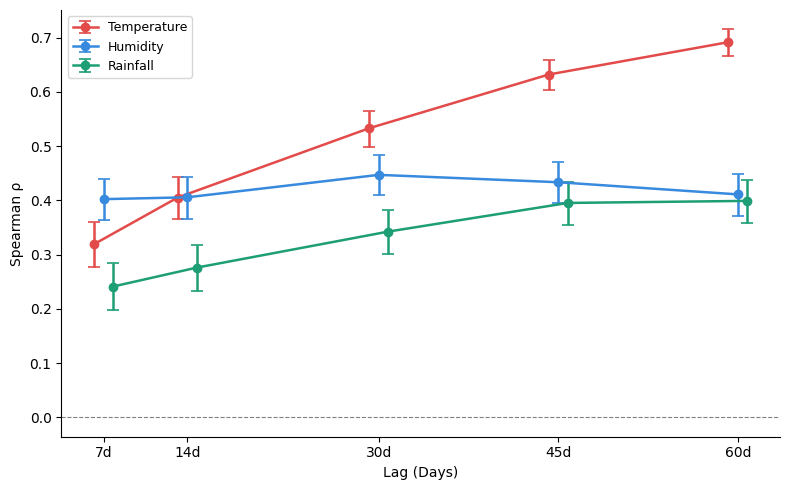

Saved: Figure_Spearman_CI_Only.png / .pdf


In [ ]:
"""
=============================================================
ENHANCED SPEARMAN CORRELATION — PANEL B ONLY
(Panel A heatmap already computed separately)
Plots: Spearman ρ with 95% CI error bars only
=============================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr

# ─────────────────────────────────────────────
# STEP 1: Load data
# ─────────────────────────────────────────────
sp_df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")
sp_df["Date"] = pd.to_datetime(sp_df["Date"])
sp_df = sp_df.sort_values("Date").set_index("Date")

# ─────────────────────────────────────────────
# STEP 2: Create lag columns
# ─────────────────────────────────────────────
lag_days = [7, 14, 30, 45, 60]

for lag in lag_days:
    sp_df[f"Temperature_Lag{lag}"] = sp_df["Temperature"].shift(lag)
    sp_df[f"Humidity_Lag{lag}"]    = sp_df["Humidity"].shift(lag)
    sp_df[f"Rainfall_Lag{lag}"]    = sp_df["Rainfall_mm"].shift(lag)

# ─────────────────────────────────────────────
# STEP 3: Helpers
# ─────────────────────────────────────────────
def spearman_ci(rho, n, alpha=0.05):
    if abs(rho) >= 1.0:
        return round(rho, 4), round(rho, 4)
    z      = np.arctanh(rho)
    se     = 1 / np.sqrt(n - 3)
    z_crit = stats.norm.ppf(1 - alpha / 2)
    return round(np.tanh(z - z_crit * se), 4), \
           round(np.tanh(z + z_crit * se), 4)

def effect_size_label(rho):
    r = abs(rho)
    if r < 0.10: return "Negligible"
    if r < 0.30: return "Small"
    if r < 0.50: return "Moderate"
    if r < 0.70: return "Large"
    return "Very Large"

# ─────────────────────────────────────────────
# STEP 4: Run analysis
# ─────────────────────────────────────────────
climate_vars = {
    "Temperature": "Temperature_Lag{}",
    "Humidity":    "Humidity_Lag{}",
    "Rainfall":    "Rainfall_Lag{}",
}

n_tests = len(lag_days) * len(climate_vars)
results = []

for lag in lag_days:
    for var_label, col_template in climate_vars.items():
        col     = col_template.format(lag)
        temp_df = sp_df[["Dengue_Cases", col]].dropna()
        n       = len(temp_df)
        rho, p_val   = spearmanr(temp_df["Dengue_Cases"], temp_df[col])
        ci_lo, ci_hi = spearman_ci(rho, n)
        p_bonf       = min(p_val * n_tests, 1.0)

        results.append({
            "Lag (Days)":       lag,
            "Variable":         var_label,
            "n":                n,
            "Spearman ρ":       round(rho, 4),
            "95% CI Lower":     ci_lo,
            "95% CI Upper":     ci_hi,
            "95% CI":           f"[{ci_lo}, {ci_hi}]",
            "p-value (fmt)":    "<0.001" if p_val < 0.001 else round(p_val, 4),
            "p Bonf (fmt)":     "<0.001" if p_bonf < 0.001 else round(p_bonf, 4),
            "Significant":      "Yes ✓" if p_val  < 0.05 else "No",
            "Sig (Bonferroni)": "Yes ✓" if p_bonf < 0.05 else "No",
            "Effect Size":      effect_size_label(rho),
            "|ρ|":              round(abs(rho), 4),
        })

results_df = pd.DataFrame(results)

# ─────────────────────────────────────────────
# STEP 5: Print table
# ─────────────────────────────────────────────
print("=" * 100)
print("ENHANCED SPEARMAN CORRELATION")
print("Dengue Cases vs Lagged Climate Variables — Dhaka 2020–2024")
print(f"Bonferroni correction: {n_tests} tests | adjusted α = {0.05/n_tests:.4f}")
print("=" * 100)

display_cols = [
    "Lag (Days)", "Variable", "n", "Spearman ρ", "95% CI",
    "p-value (fmt)", "p Bonf (fmt)", "Significant", "Sig (Bonferroni)", "Effect Size"
]
print(results_df[display_cols].to_string(index=False))

# ─────────────────────────────────────────────
# STEP 6: Best lag per variable
# ─────────────────────────────────────────────
best_lags = (
    results_df.sort_values("|ρ|", ascending=False)
    .groupby("Variable").first().reset_index()
    [["Variable","Lag (Days)","Spearman ρ","95% CI","p-value (fmt)","Effect Size"]]
)
print("\n" + "="*65)
print("OPTIMAL LAG PER CLIMATE VARIABLE")
print("="*65)
print(best_lags.to_string(index=False))

# ─────────────────────────────────────────────
# STEP 7: Save
# ─────────────────────────────────────────────
results_df.to_csv("Spearman_Enhanced_Full.csv", index=False)
best_lags.to_csv("Spearman_Best_Lags.csv",      index=False)
print("\nSaved: Spearman_Enhanced_Full.csv")
print("Saved: Spearman_Best_Lags.csv")

# ─────────────────────────────────────────────
# STEP 8: FIGURE — Panel B only (CI error bars)
# ─────────────────────────────────────────────
colors  = {"Temperature": "#E24B4A",
           "Humidity":    "#378ADD",
           "Rainfall":    "#1D9E75"}
offsets = {"Temperature": -0.8,
           "Humidity":     0.0,
           "Rainfall":     0.8}

fig, ax = plt.subplots(figsize=(8, 5))

for var in climate_vars.keys():
    sub    = results_df[results_df.Variable == var].copy()
    x      = np.array(lag_days, dtype=float) + offsets[var]
    rhos   = sub["Spearman ρ"].values
    ci_lo  = sub["95% CI Lower"].values
    ci_hi  = sub["95% CI Upper"].values

    ax.errorbar(
        x, rhos,
        yerr=[rhos - ci_lo, ci_hi - rhos],
        fmt="o-", color=colors[var],
        linewidth=1.8, markersize=6,
        capsize=4, capthick=1.2,
        label=var
    )

ax.axhline(0, color="black", lw=0.8, linestyle="--", alpha=0.5)
ax.set_xticks(lag_days)
ax.set_xticklabels([f"{l}d" for l in lag_days], fontsize=10)
ax.set_xlabel("Lag (Days)", fontsize=10)
ax.set_ylabel("Spearman ρ", fontsize=10)
#ax.set_title(
    #"Spearman ρ with 95% Confidence Intervals\n"
    #"Dengue Cases vs Lagged Climate Variables — Dhaka 2020–2024\n"
    #"(Fisher Z method, Bonferroni corrected)",
    #fontsize=10, fontweight="bold"
#)
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("Figure_Spearman_CI_Only.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("Figure_Spearman_CI_Only.pdf",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: Figure_Spearman_CI_Only.png / .pdf")

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from itertools import product

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 1) Load dataset

df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")


# 2) Convert Date and build DAILY dengue series
#    - sums if multiple rows per day
#    - ensures all days exist (missing -> 0)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

y = (
    df.set_index("Date")
      .resample("D")["Dengue_Cases"]
      .sum()
      .asfreq("D", fill_value=0)
)

print("Freq:", y.index.inferred_freq)
print("Total days:", len(y))


# 3) 80/20 Chronological split

split_index = int(len(y) * 0.8)
train = y.iloc[:split_index]
test  = y.iloc[split_index:]

print("Train:", train.index.min(), "to", train.index.max(), "| n=", len(train))
print("Test :", test.index.min(),  "to", test.index.max(),  "| n=", len(test))


# 4) Metrics

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def smape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100


# 5) SARIMA search space (DAILY)
#    Common daily seasonality: weekly = 7

s = 7  # weekly seasonality

p = [0, 1, 2]
d = [0, 1]
q = [0, 1, 2]
P = [0, 1, 2]
D = [0, 1]
Q = [0, 1, 2]

candidates = list(product(p, d, q, P, D, Q))[:60]


# 6) Fit + evaluate

results = []

for (p_, d_, q_, P_, D_, Q_) in candidates:
    try:
        model = SARIMAX(
            train,
            order=(p_, d_, q_),
            seasonal_order=(P_, D_, Q_, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fit = model.fit(disp=False)

        forecast = fit.get_forecast(steps=len(test)).predicted_mean
        forecast = forecast.clip(lower=0)

        results.append({
            "order": (p_, d_, q_),
            "seasonal_order": (P_, D_, Q_, s),
            "AIC": fit.aic,
            "RMSE": rmse(test, forecast),
            "MAE": mae(test, forecast),
            "SMAPE(%)": smape(test, forecast),
            "R2": r2_score(test, forecast)
        })

    except:
        continue

results_df = pd.DataFrame(results)
print(f"\n Successfully fitted {len(results_df)} combination SARIMA models")


# 7) Best model by RMSE

best = results_df.sort_values("RMSE").iloc[0]

print("\n Best Daily SARIMA (80/20 split) by RMSE")
print(best)


Freq: D
Total days: 1826
Train: 2020-01-01 00:00:00 to 2023-12-30 00:00:00 | n= 1460
Test : 2023-12-31 00:00:00 to 2024-12-30 00:00:00 | n= 366

 Successfully fitted 60 combination SARIMA models

 Best Daily SARIMA (80/20 split) by RMSE
order                (0, 0, 2)
seasonal_order    (2, 1, 2, 7)
AIC               16511.579425
RMSE                164.275983
MAE                 106.682576
SMAPE(%)             127.27946
R2                   -0.195802
Name: 53, dtype: object


In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 0) Imports
# ============================================================
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam


# ============================================================
# 1) Load & prepare data
# ============================================================
df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

target = "Dengue_Cases"


# 2) Create lag features (BASED ON  BEST LAGS)
#    Dengue lags: 7, 14, 30
#    Climate lags: Temp 60, Humidity 30, Rainfall 45

dengue_lags = [7, 14, 30]

df["Temperature_Lag60"] = df["Temperature"].shift(60)
df["Humidity_Lag30"]    = df["Humidity"].shift(30)
df["Rainfall_Lag45"]    = df["Rainfall_mm"].shift(45)

for lag in dengue_lags:
    df[f"Dengue_Lag{lag}"] = df[target].shift(lag)

features = [
    "Temperature_Lag60",
    "Humidity_Lag30",
    "Rainfall_Lag45",
    "Dengue_Lag7",
    "Dengue_Lag14",
    "Dengue_Lag30",
]

# keep only rows where everything needed is present
df_ml = df.dropna(subset=[target] + features).copy()

X = df_ml[features].values
y = df_ml[target].values


# ============================================================
# 3) Train-test split (time-based)
# ============================================================
split_idx = int(len(df_ml) * 0.80)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]


# ============================================================
# 4) Evaluation function (safe for zeros)
# ============================================================
def evaluate_model(name, y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    y_true = np.array(y_true, dtype=float)

    mask = y_true != 0
    mape = (
        np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        if mask.sum() else np.nan
    )

    denom = np.abs(y_true) + np.abs(y_pred)
    mask2 = denom != 0
    smape = (
        np.mean(200 * np.abs(y_pred[mask2] - y_true[mask2]) / denom[mask2])
        if mask2.sum() else np.nan
    )

    return {
        "Model": name,
        "RMSE": rmse,
        "MSE": mse,
        "MAE": mae,
        "MAPE (%)": mape,
        "SMAPE (%)": smape,
        "R2": r2
    }


results = []


# ============================================================
# 6) Linear Models
# ============================================================
lr = LinearRegression()
lr.fit(X_train, y_train)
results.append(evaluate_model("Linear Regression", y_test, lr.predict(X_test)))

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
results.append(evaluate_model("Ridge Regression", y_test, ridge.predict(X_test)))


# ============================================================
# 7) Tree-Based Models
# ============================================================
rf = RandomForestRegressor(n_estimators=400, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate_model("Random Forest", y_test, rf.predict(X_test)))

etr = ExtraTreesRegressor(n_estimators=400, max_depth=10, random_state=42, n_jobs=-1)
etr.fit(X_train, y_train)
results.append(evaluate_model("Extra Trees", y_test, etr.predict(X_test)))


# ============================================================
# 8) Boosting Models
# ============================================================
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)
xgb.fit(X_train, y_train)
results.append(evaluate_model("XGBoost", y_test, xgb.predict(X_test)))

lgbm = LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    random_state=42
)
lgbm.fit(X_train, y_train)
results.append(evaluate_model("LightGBM", y_test, lgbm.predict(X_test)))


# ============================================================
# 9) SVR (needs scaling)
# ============================================================
svr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))
])
svr.fit(X_train, y_train)
results.append(evaluate_model("SVR (RBF)", y_test, svr.predict(X_test)))


# ============================================================
# 10) MLP (needs scaling)
# ============================================================
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1500, random_state=42))
])
mlp.fit(X_train, y_train)
results.append(evaluate_model("MLP Neural Network", y_test, mlp.predict(X_test)))


# ============================================================
# 11) LSTM (proper daily sequence model)
#     Use window = 60 days (because Temp_Lag60 was strongest)
#     Features per day: [Dengue, Temperature, Humidity, Rainfall]
# ============================================================
window = 60

base_cols = ["Dengue_Cases", "Temperature", "Humidity", "Rainfall_mm"]
base = df[base_cols].copy().dropna()

# build sequences
X_seq, y_seq = [], []
vals = base.values  # (N, 4)

for i in range(window, len(base)):
    X_seq.append(vals[i-window:i, :])  # past 60 days
    y_seq.append(vals[i, 0])           # Dengue_Cases today

X_seq = np.array(X_seq, dtype=np.float32)  # (samples, 60, 4)
y_seq = np.array(y_seq, dtype=np.float32)

# time split for sequences (same 80/20)
split_s = int(len(X_seq) * 0.80)
X_train_lstm, X_test_lstm = X_seq[:split_s], X_seq[split_s:]
y_train_lstm, y_test_lstm = y_seq[:split_s], y_seq[split_s:]

lstm_model = Sequential([
    LSTM(64, activation="tanh", input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

lstm_model.fit(X_train_lstm, y_train_lstm, epochs=40, batch_size=32, verbose=0)

y_pred_lstm = lstm_model.predict(X_test_lstm, verbose=0).flatten()
results.append(evaluate_model("LSTM (Window=60)", y_test_lstm, y_pred_lstm))
# ============================================================
# 8b) CatBoost
# ============================================================
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)
cat.fit(X_train, y_train)
results.append(evaluate_model("CatBoost", y_test, cat.predict(X_test)))


# ============================================================
# 12) Results Table
# ============================================================
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\n=== MODEL COMPARISON RESULTS (BEST LAGS) ===")
print(results_df.round(3))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1028
[LightGBM] [Info] Number of data points in the train set: 1412, number of used features: 6
[LightGBM] [Info] Start training from score 167.128895
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



=== MODEL COMPARISON RESULTS (BEST LAGS) ===
                Model     RMSE        MSE     MAE  MAPE (%)  SMAPE (%)     R2
3         Extra Trees   48.666   2368.338  28.886   115.498     53.843  0.897
1    Ridge Regression   49.405   2440.894  30.881   126.251     68.486  0.894
0   Linear Regression   49.405   2440.895  30.881   126.250     68.487  0.894
7  MLP Neural Network   51.828   2686.156  30.438   111.831     64.091  0.883
9            CatBoost   54.927   3016.980  32.093   107.522     56.649  0.869
2       Random Forest   55.582   3089.392  33.289   143.133     56.011  0.866
4             XGBoost   57.620   3320.034  34.062   123.020     60.786  0.856
5            LightGBM   58.536   3426.428  35.169   111.877     67.180  0.851
6           SVR (RBF)   69.538   4835.469  36.923    79.142     55.695  0.790
8    LSTM (Window=60)  136.983  18764.324  73.837    89.139     68.210  0.186


Split 1 — Train: 2020–2023 | Test: 2024
RMSE: 49.16 | MAE: 31.12 | R²: 0.893

Split 2 — Train: 2020–2022 | Test: 2023
RMSE: 153.40 | MAE: 86.24 | R²: 0.827


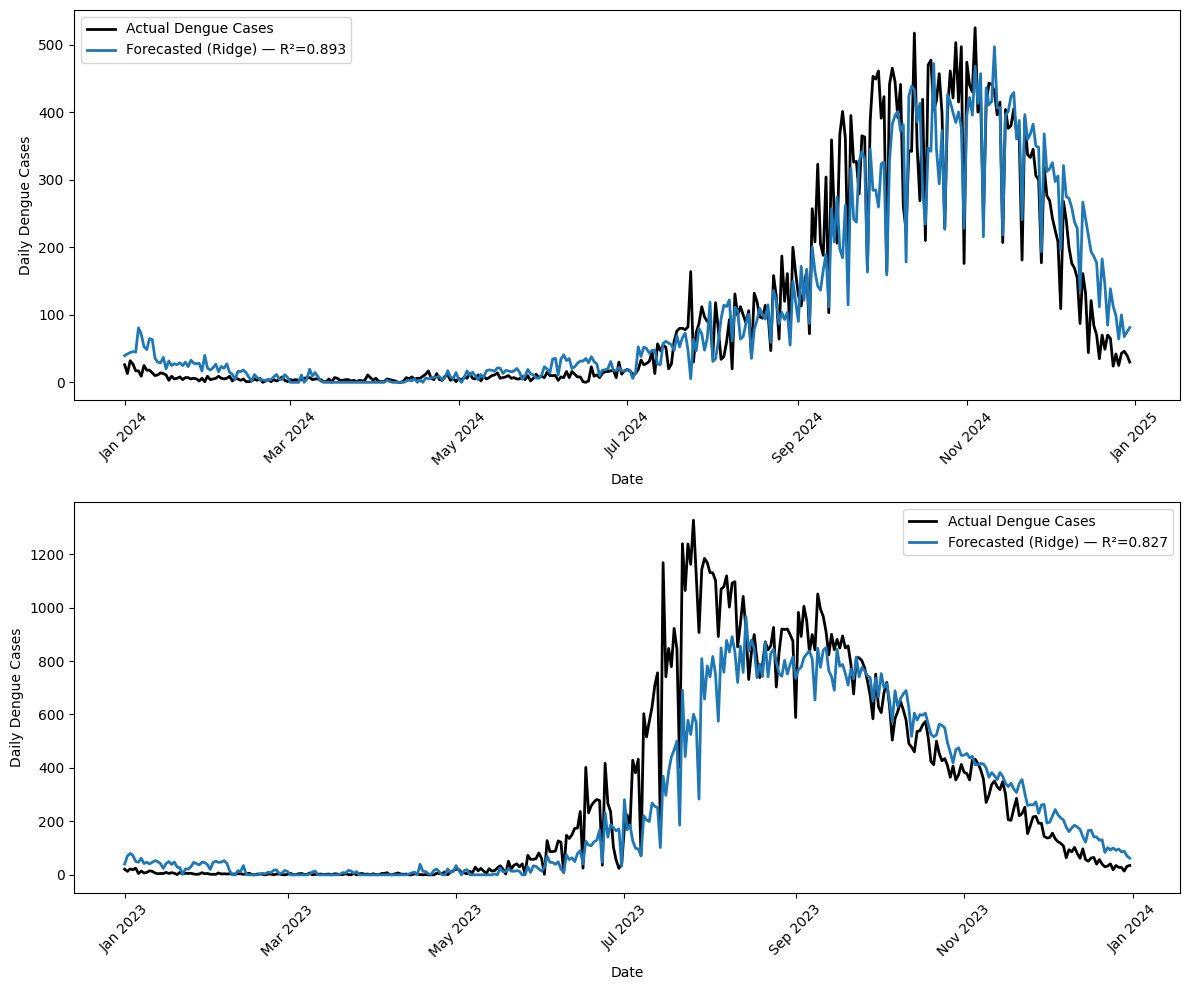

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 1) Load data
file_path = "/content/dhaka_dengue_weather_2020_2024.csv"
df = pd.read_csv(file_path)


# 2) Ensure Date index
date_candidates = ["Date", "date", "DATE", "Time", "time", "Datetime", "datetime"]

date_col = None
for c in date_candidates:
    if c in df.columns:
        date_col = c
        break

if date_col is None:
    first_col = df.columns[0]
    try:
        pd.to_datetime(df[first_col], errors="raise")
        date_col = first_col
    except Exception:
        date_col = None

if date_col is not None:
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).set_index(date_col)
else:
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()


# 3) Validate required columns
target_col = "Dengue_Cases"
climate_cols = ["Temperature", "Humidity", "Rainfall_mm"]

missing = [c for c in [target_col] + climate_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")


# 4) Daily aggregation
df_daily = (
    df[[target_col] + climate_cols]
    .resample("D")
    .agg({
        target_col: "sum",
        "Temperature": "mean",
        "Humidity": "mean",
        "Rainfall_mm": "sum"
    })
    .asfreq("D")
)

df_daily[target_col] = df_daily[target_col].fillna(0)
df_daily["Temperature"] = df_daily["Temperature"].ffill()
df_daily["Humidity"]    = df_daily["Humidity"].ffill()
df_daily["Rainfall_mm"] = df_daily["Rainfall_mm"].ffill()


# 5) Feature engineering
df_daily["Temperature_Lag60"] = df_daily["Temperature"].shift(60)
df_daily["Humidity_Lag30"]    = df_daily["Humidity"].shift(30)
df_daily["Rainfall_Lag45"]    = df_daily["Rainfall_mm"].shift(45)

df_daily["Dengue_Lag7"]  = df_daily[target_col].shift(7)
df_daily["Dengue_Lag14"] = df_daily[target_col].shift(14)
df_daily["Dengue_Lag30"] = df_daily[target_col].shift(30)

features = [
    "Temperature_Lag60",
    "Humidity_Lag30",
    "Rainfall_Lag45",
    "Dengue_Lag7",
    "Dengue_Lag14",
    "Dengue_Lag30",
]

df_ml = df_daily.dropna(subset=features + [target_col]).copy()
X = df_ml[features]
y = df_ml[target_col]


# ============================================================
# 6) SPLIT 1 — Train: 2020–2023 | Test: 2024
# ============================================================
train_s1 = df_ml[df_ml.index.year <= 2023]
test_s1  = df_ml[df_ml.index.year == 2024]

X_train_s1, y_train_s1 = train_s1[features], train_s1[target_col]
X_test_s1,  y_test_s1  = test_s1[features],  test_s1[target_col]

ridge_s1 = Ridge(alpha=1.0)
ridge_s1.fit(X_train_s1, y_train_s1)
y_pred_s1 = np.clip(ridge_s1.predict(X_test_s1), 0, None)

rmse_s1 = np.sqrt(mean_squared_error(y_test_s1, y_pred_s1))
mae_s1  = mean_absolute_error(y_test_s1, y_pred_s1)
r2_s1   = r2_score(y_test_s1, y_pred_s1)

print("Split 1 — Train: 2020–2023 | Test: 2024")
print(f"RMSE: {rmse_s1:.2f} | MAE: {mae_s1:.2f} | R²: {r2_s1:.3f}\n")


# ============================================================
# 7) SPLIT 2 — Train: 2020–2022 | Test: 2023
# ============================================================
train_s2 = df_ml[df_ml.index.year <= 2022]
test_s2  = df_ml[df_ml.index.year == 2023]

X_train_s2, y_train_s2 = train_s2[features], train_s2[target_col]
X_test_s2,  y_test_s2  = test_s2[features],  test_s2[target_col]

ridge_s2 = Ridge(alpha=1.0)
ridge_s2.fit(X_train_s2, y_train_s2)
y_pred_s2 = np.clip(ridge_s2.predict(X_test_s2), 0, None)

rmse_s2 = np.sqrt(mean_squared_error(y_test_s2, y_pred_s2))
mae_s2  = mean_absolute_error(y_test_s2, y_pred_s2)
r2_s2   = r2_score(y_test_s2, y_pred_s2)

print("Split 2 — Train: 2020–2022 | Test: 2023")
print(f"RMSE: {rmse_s2:.2f} | MAE: {mae_s2:.2f} | R²: {r2_s2:.3f}")


# ============================================================
# 8) Combined Plot
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ---- Split 1 (Top) ----
ax1.plot(test_s1.index, y_test_s1.values,
         label="Actual Dengue Cases", color="black", linewidth=2)
ax1.plot(test_s1.index, y_pred_s1,
         label=f"Forecasted (Ridge) — R²={r2_s1:.3f}", linewidth=2)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
#ax1.set_title("Split 1: Train 2020–2023 | Test 2024", fontsize=13, fontweight="bold")
ax1.set_xlabel("Date")
ax1.set_ylabel("Daily Dengue Cases")
ax1.legend()

# ---- Split 2 (Bottom) ----
ax2.plot(test_s2.index, y_test_s2.values,
         label="Actual Dengue Cases", color="black", linewidth=2)
ax2.plot(test_s2.index, y_pred_s2,
         label=f"Forecasted (Ridge) — R²={r2_s2:.3f}", linewidth=2)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
#ax2.set_title("Split 2: Train 2020–2022 | Test 2023", fontsize=13, fontweight="bold")
ax2.set_xlabel("Date")
ax2.set_ylabel("Daily Dengue Cases")
ax2.legend()

plt.tight_layout()
plt.savefig("ridge_robustness_split1_split2.png", dpi=150, bbox_inches="tight")
plt.savefig("ridge_robustness_split1_split2.pdf", bbox_inches="tight")
plt.show()

Ridge Regression trained on FULL 2020–2024 data.


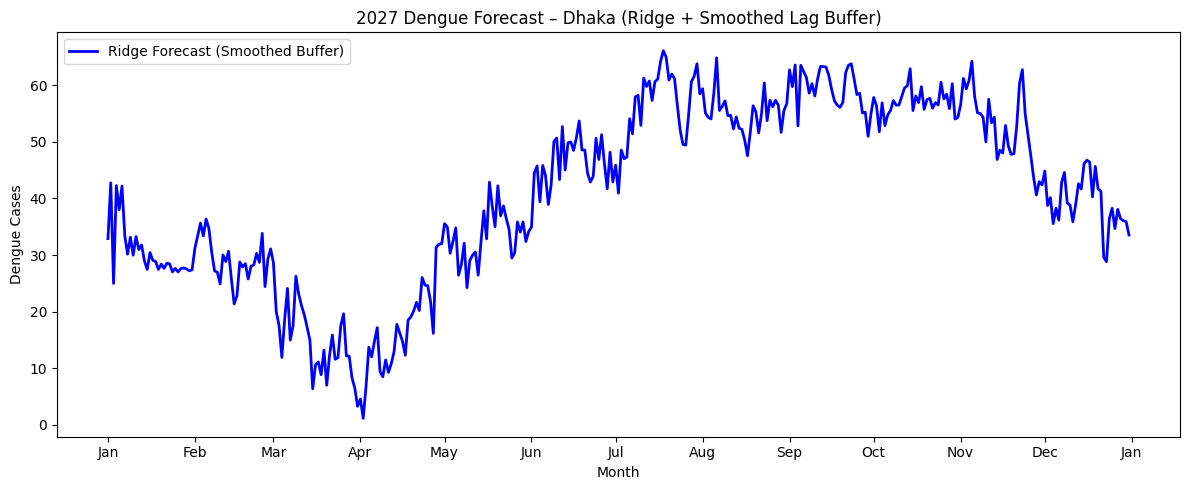

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import Ridge
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ============================================================
# 1) Load & Prepare Data
# ============================================================
df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df = df.groupby("Date", as_index=False).agg({
    "Dengue_Cases": "sum",
    "Temperature": "mean",
    "Humidity": "mean",
    "Rainfall_mm": "sum"
})

df = df.set_index("Date").sort_index()

full_hist_index = pd.date_range(df.index.min(), df.index.max(), freq="D")
df_daily = df.reindex(full_hist_index)

df_daily["Dengue_Cases"] = df_daily["Dengue_Cases"].fillna(0)
df_daily["Temperature"] = df_daily["Temperature"].interpolate().ffill().bfill()
df_daily["Humidity"]    = df_daily["Humidity"].interpolate().ffill().bfill()
df_daily["Rainfall_mm"] = df_daily["Rainfall_mm"].fillna(0)

target_col = "Dengue_Cases"

# ============================================================
# 2) Lag Features
# ============================================================
df_daily["Temperature_Lag60"] = df_daily["Temperature"].shift(60)
df_daily["Humidity_Lag30"]    = df_daily["Humidity"].shift(30)
df_daily["Rainfall_Lag45"]    = df_daily["Rainfall_mm"].shift(45)

df_daily["Dengue_Lag7"]  = df_daily[target_col].shift(7)
df_daily["Dengue_Lag14"] = df_daily[target_col].shift(14)
df_daily["Dengue_Lag30"] = df_daily[target_col].shift(30)

feature_cols = [
    "Temperature_Lag60",
    "Humidity_Lag30",
    "Rainfall_Lag45",
    "Dengue_Lag7",
    "Dengue_Lag14",
    "Dengue_Lag30"
]

df_ml = df_daily.dropna(subset=feature_cols + [target_col]).copy()
X_full = df_ml[feature_cols]
y_full = df_ml[target_col]

# ============================================================
# 3) Train Ridge
# ============================================================
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_full, y_full)

print("Ridge Regression trained on FULL 2020–2024 data.")

# ============================================================
# 4) Forecast Climate
# ============================================================
forecast_start = pd.Timestamp("2027-01-01")
forecast_end   = pd.Timestamp("2027-12-31")
future_index   = pd.date_range(forecast_start, forecast_end, freq="D")

climate_future = pd.DataFrame(index=future_index)

def hw_forecast(series, steps, seasonal_periods=365, seasonal="add"):
    model = ExponentialSmoothing(
        series,
        trend=None,
        seasonal=seasonal,
        seasonal_periods=seasonal_periods,
        initialization_method="estimated"
    )
    fit = model.fit(optimized=True)
    return fit.forecast(steps)

for col in ["Temperature", "Humidity"]:
    climate_future[col] = np.array(
        hw_forecast(df_daily[col], steps=len(future_index))
    )

rf_fc = hw_forecast(df_daily["Rainfall_mm"], steps=len(future_index))
climate_future["Rainfall_mm"] = np.clip(np.array(rf_fc), 0, None)

climate_all = pd.concat([df_daily[["Temperature", "Humidity", "Rainfall_mm"]], climate_future])
climate_all = climate_all.reindex(pd.date_range(climate_all.index.min(), climate_all.index.max(), freq="D"))

climate_all["Temperature"] = climate_all["Temperature"].interpolate().ffill().bfill()
climate_all["Humidity"]    = climate_all["Humidity"].interpolate().ffill().bfill()
climate_all["Rainfall_mm"] = climate_all["Rainfall_mm"].fillna(0)

# ============================================================
# 5) Recursive Forecasting with Smoothed Lag Buffer (Option 1)
# ============================================================
lag_buffer = df_daily[target_col].iloc[-60:].tolist()

preds = []

for dt in future_index:
    row = {
        "Temperature_Lag60": climate_all.loc[dt - pd.Timedelta(days=60), "Temperature"],
        "Humidity_Lag30":    climate_all.loc[dt - pd.Timedelta(days=30), "Humidity"],
        "Rainfall_Lag45":    climate_all.loc[dt - pd.Timedelta(days=45), "Rainfall_mm"],
        "Dengue_Lag7":       lag_buffer[-7],
        "Dengue_Lag14":      lag_buffer[-14],
        "Dengue_Lag30":      lag_buffer[-30],
    }

    X_row = pd.DataFrame([row])[feature_cols]

    y_hat = ridge_model.predict(X_row)[0]
    y_hat = max(0, y_hat)

    preds.append(y_hat)

    # ✅ Option 1: Feed back a 7-day rolling mean instead of raw prediction
    smoothed = np.mean(lag_buffer[-7:])
    lag_buffer.append(smoothed)
    lag_buffer = lag_buffer[-60:]

future_forecast = pd.DataFrame({"Predicted_Dengue": preds}, index=future_index)

# ============================================================
# 6) Plot
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(future_forecast.index, future_forecast["Predicted_Dengue"],
         color="blue", linewidth=2, label="Ridge Forecast (Smoothed Buffer)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.xlabel("Month")
plt.ylabel("Dengue Cases")
plt.title("2027 Dengue Forecast – Dhaka (Ridge + Smoothed Lag Buffer)")
plt.legend()
plt.tight_layout()
plt.show()

Ridge Regression trained on FULL 2020–2024 data.


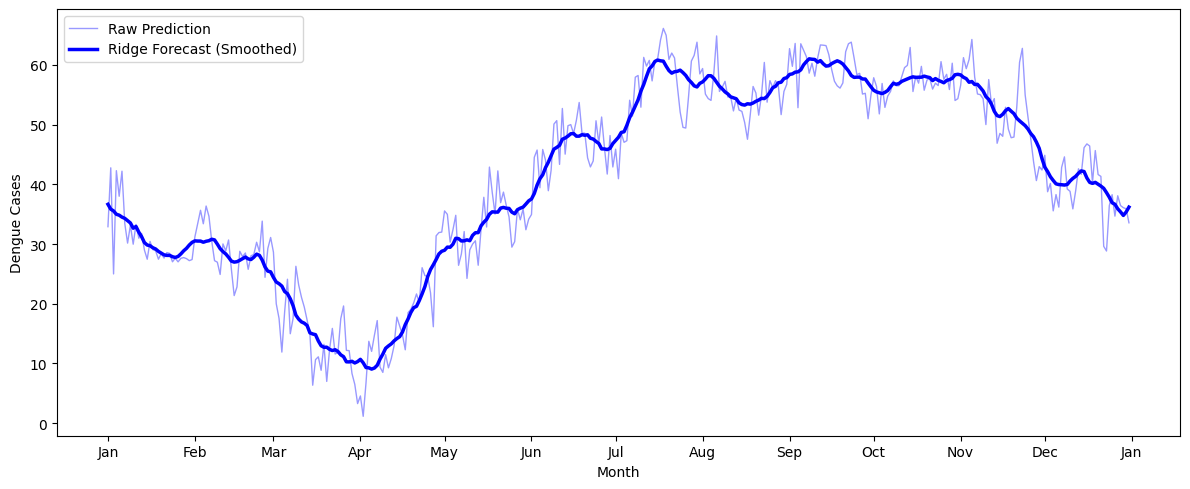

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import Ridge
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ============================================================
# 1) Load & Prepare Data
# ============================================================
df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df = df.groupby("Date", as_index=False).agg({
    "Dengue_Cases": "sum",
    "Temperature": "mean",
    "Humidity": "mean",
    "Rainfall_mm": "sum"
})

df = df.set_index("Date").sort_index()

full_hist_index = pd.date_range(df.index.min(), df.index.max(), freq="D")
df_daily = df.reindex(full_hist_index)

df_daily["Dengue_Cases"] = df_daily["Dengue_Cases"].fillna(0)
df_daily["Temperature"] = df_daily["Temperature"].interpolate().ffill().bfill()
df_daily["Humidity"]    = df_daily["Humidity"].interpolate().ffill().bfill()
df_daily["Rainfall_mm"] = df_daily["Rainfall_mm"].fillna(0)

target_col = "Dengue_Cases"

# ============================================================
# 2) Lag Features
# ============================================================
df_daily["Temperature_Lag60"] = df_daily["Temperature"].shift(60)
df_daily["Humidity_Lag30"]    = df_daily["Humidity"].shift(30)
df_daily["Rainfall_Lag45"]    = df_daily["Rainfall_mm"].shift(45)

df_daily["Dengue_Lag7"]  = df_daily[target_col].shift(7)
df_daily["Dengue_Lag14"] = df_daily[target_col].shift(14)
df_daily["Dengue_Lag30"] = df_daily[target_col].shift(30)

feature_cols = [
    "Temperature_Lag60",
    "Humidity_Lag30",
    "Rainfall_Lag45",
    "Dengue_Lag7",
    "Dengue_Lag14",
    "Dengue_Lag30"
]

df_ml = df_daily.dropna(subset=feature_cols + [target_col]).copy()
X_full = df_ml[feature_cols]
y_full = df_ml[target_col]

# ============================================================
# 3) Train Ridge
# ============================================================
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_full, y_full)

print("Ridge Regression trained on FULL 2020–2024 data.")

# ============================================================
# 4) Forecast Climate
# ============================================================
forecast_start = pd.Timestamp("2027-01-01")
forecast_end   = pd.Timestamp("2027-12-31")
future_index   = pd.date_range(forecast_start, forecast_end, freq="D")

climate_future = pd.DataFrame(index=future_index)

def hw_forecast(series, steps, seasonal_periods=365, seasonal="add"):
    model = ExponentialSmoothing(
        series,
        trend=None,
        seasonal=seasonal,
        seasonal_periods=seasonal_periods,
        initialization_method="estimated"
    )
    fit = model.fit(optimized=True)
    return fit.forecast(steps)

for col in ["Temperature", "Humidity"]:
    climate_future[col] = np.array(
        hw_forecast(df_daily[col], steps=len(future_index))
    )

rf_fc = hw_forecast(df_daily["Rainfall_mm"], steps=len(future_index))
climate_future["Rainfall_mm"] = np.clip(np.array(rf_fc), 0, None)

climate_all = pd.concat([df_daily[["Temperature", "Humidity", "Rainfall_mm"]], climate_future])
climate_all = climate_all.reindex(pd.date_range(climate_all.index.min(), climate_all.index.max(), freq="D"))

climate_all["Temperature"] = climate_all["Temperature"].interpolate().ffill().bfill()
climate_all["Humidity"]    = climate_all["Humidity"].interpolate().ffill().bfill()
climate_all["Rainfall_mm"] = climate_all["Rainfall_mm"].fillna(0)

# ============================================================
# 5) Recursive Forecasting with Smoothed Lag Buffer (Option 1)
# ============================================================
lag_buffer = df_daily[target_col].iloc[-60:].tolist()

preds = []

for dt in future_index:
    row = {
        "Temperature_Lag60": climate_all.loc[dt - pd.Timedelta(days=60), "Temperature"],
        "Humidity_Lag30":    climate_all.loc[dt - pd.Timedelta(days=30), "Humidity"],
        "Rainfall_Lag45":    climate_all.loc[dt - pd.Timedelta(days=45), "Rainfall_mm"],
        "Dengue_Lag7":       lag_buffer[-7],
        "Dengue_Lag14":      lag_buffer[-14],
        "Dengue_Lag30":      lag_buffer[-30],
    }

    X_row = pd.DataFrame([row])[feature_cols]

    y_hat = ridge_model.predict(X_row)[0]
    y_hat = max(0, y_hat)

    preds.append(y_hat)

    # ✅ Option 1: Feed back a 7-day rolling mean instead of raw prediction
    smoothed = np.mean(lag_buffer[-7:])
    lag_buffer.append(smoothed)
    lag_buffer = lag_buffer[-60:]

future_forecast = pd.DataFrame({"Predicted_Dengue": preds}, index=future_index)

# ============================================================
# 6) Plot
# ============================================================

# Apply 14-day centered rolling mean to smooth residual oscillation
future_forecast["Smoothed_Dengue"] = (
    future_forecast["Predicted_Dengue"]
    .rolling(window=14, center=True, min_periods=1)
    .mean()
)

plt.figure(figsize=(12, 5))

# Optional: show raw prediction as faint background
plt.plot(future_forecast.index, future_forecast["Predicted_Dengue"],
         color="blue", linewidth=1, alpha=0.4, label="Raw Prediction")

# Main smoothed line
plt.plot(future_forecast.index, future_forecast["Smoothed_Dengue"],
         color="blue", linewidth=2.5, label="Ridge Forecast (Smoothed)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.xlabel("Month")
plt.ylabel("Dengue Cases")
#plt.title("2027 Dengue Forecast – Dhaka")
plt.legend()
plt.tight_layout()
plt.savefig("2027_dengue_forecast_dhaka.png", dpi=150, bbox_inches="tight")
plt.savefig("2027_dengue_forecast_dhaka.pdf", bbox_inches="tight")
plt.show()

Ridge Regression trained on FULL 2020–2024 data.
🔴 PEAK OUTBREAK MONTH: September 2027
📊 Total Predicted Cases : 1780
📈 Peak Daily Cases      : 61.0
📉 Min Daily Cases       : 56.3
📋 Avg Daily Cases       : 59.3

🟠 PRE-OUTBREAK MONTH   : August 2027
📊 Total Predicted Cases : 1723
📈 Peak Daily Cases      : 58.2
📉 Min Daily Cases       : 53.3
📋 Avg Daily Cases       : 55.6
⚠️  Action Window        : Intervene during August 2027 to reduce peak burden


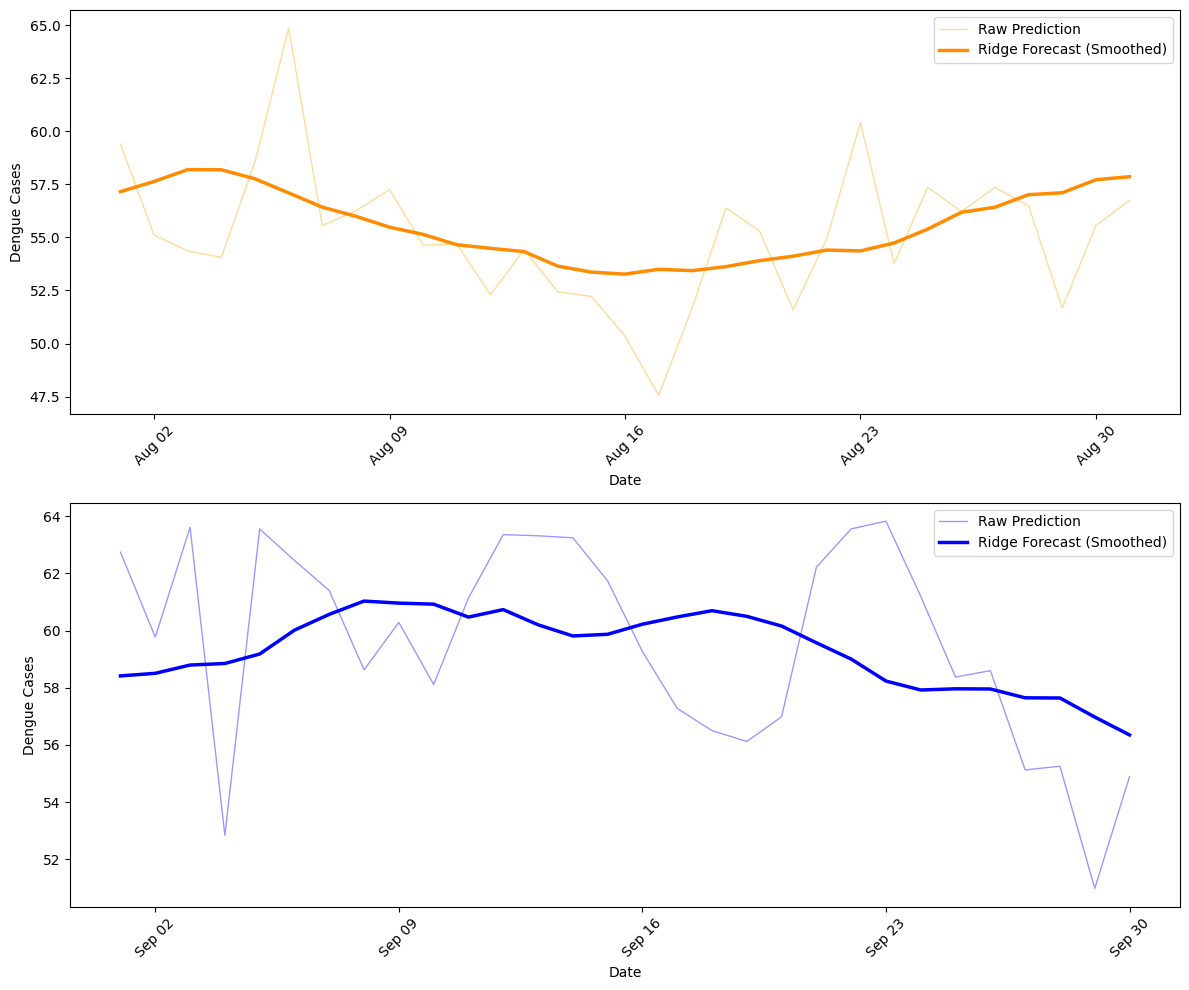

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import Ridge
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ============================================================
# 1) Load & Prepare Data
# ============================================================
df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df = df.groupby("Date", as_index=False).agg({
    "Dengue_Cases": "sum",
    "Temperature": "mean",
    "Humidity": "mean",
    "Rainfall_mm": "sum"
})

df = df.set_index("Date").sort_index()

full_hist_index = pd.date_range(df.index.min(), df.index.max(), freq="D")
df_daily = df.reindex(full_hist_index)

df_daily["Dengue_Cases"] = df_daily["Dengue_Cases"].fillna(0)
df_daily["Temperature"] = df_daily["Temperature"].interpolate().ffill().bfill()
df_daily["Humidity"]    = df_daily["Humidity"].interpolate().ffill().bfill()
df_daily["Rainfall_mm"] = df_daily["Rainfall_mm"].fillna(0)

target_col = "Dengue_Cases"

# ============================================================
# 2) Lag Features
# ============================================================
df_daily["Temperature_Lag60"] = df_daily["Temperature"].shift(60)
df_daily["Humidity_Lag30"]    = df_daily["Humidity"].shift(30)
df_daily["Rainfall_Lag45"]    = df_daily["Rainfall_mm"].shift(45)

df_daily["Dengue_Lag7"]  = df_daily[target_col].shift(7)
df_daily["Dengue_Lag14"] = df_daily[target_col].shift(14)
df_daily["Dengue_Lag30"] = df_daily[target_col].shift(30)

feature_cols = [
    "Temperature_Lag60",
    "Humidity_Lag30",
    "Rainfall_Lag45",
    "Dengue_Lag7",
    "Dengue_Lag14",
    "Dengue_Lag30"
]

df_ml = df_daily.dropna(subset=feature_cols + [target_col]).copy()
X_full = df_ml[feature_cols]
y_full = df_ml[target_col]

# ============================================================
# 3) Train Ridge
# ============================================================
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_full, y_full)

print("Ridge Regression trained on FULL 2020–2024 data.")

# ============================================================
# 4) Forecast Climate — Full Year
# ============================================================
forecast_start = pd.Timestamp("2027-01-01")
forecast_end   = pd.Timestamp("2027-12-31")
future_index   = pd.date_range(forecast_start, forecast_end, freq="D")

climate_future = pd.DataFrame(index=future_index)

def hw_forecast(series, steps, seasonal_periods=365, seasonal="add"):
    model = ExponentialSmoothing(
        series,
        trend=None,
        seasonal=seasonal,
        seasonal_periods=seasonal_periods,
        initialization_method="estimated"
    )
    fit = model.fit(optimized=True)
    return fit.forecast(steps)

for col in ["Temperature", "Humidity"]:
    climate_future[col] = np.array(
        hw_forecast(df_daily[col], steps=len(future_index))
    )

rf_fc = hw_forecast(df_daily["Rainfall_mm"], steps=len(future_index))
climate_future["Rainfall_mm"] = np.clip(np.array(rf_fc), 0, None)

climate_all = pd.concat([df_daily[["Temperature", "Humidity", "Rainfall_mm"]], climate_future])
climate_all = climate_all.reindex(pd.date_range(climate_all.index.min(), climate_all.index.max(), freq="D"))

climate_all["Temperature"] = climate_all["Temperature"].interpolate().ffill().bfill()
climate_all["Humidity"]    = climate_all["Humidity"].interpolate().ffill().bfill()
climate_all["Rainfall_mm"] = climate_all["Rainfall_mm"].fillna(0)

# ============================================================
# 5) Recursive Forecasting — Full Year (Option 1)
# ============================================================
lag_buffer = df_daily[target_col].iloc[-60:].tolist()
preds = []

for dt in future_index:
    row = {
        "Temperature_Lag60": climate_all.loc[dt - pd.Timedelta(days=60), "Temperature"],
        "Humidity_Lag30":    climate_all.loc[dt - pd.Timedelta(days=30), "Humidity"],
        "Rainfall_Lag45":    climate_all.loc[dt - pd.Timedelta(days=45), "Rainfall_mm"],
        "Dengue_Lag7":       lag_buffer[-7],
        "Dengue_Lag14":      lag_buffer[-14],
        "Dengue_Lag30":      lag_buffer[-30],
    }

    X_row = pd.DataFrame([row])[feature_cols]
    y_hat = ridge_model.predict(X_row)[0]
    y_hat = max(0, y_hat)

    preds.append(y_hat)
    smoothed = np.mean(lag_buffer[-7:])
    lag_buffer.append(smoothed)
    lag_buffer = lag_buffer[-60:]

future_forecast = pd.DataFrame({"Predicted_Dengue": preds}, index=future_index)

# ============================================================
# 6) Apply Option 3 — 14-day Rolling Mean
# ============================================================
future_forecast["Smoothed_Dengue"] = (
    future_forecast["Predicted_Dengue"]
    .rolling(window=14, center=True, min_periods=1)
    .mean()
)

# ============================================================
# 7) Auto-Detect Peak Month & Pre-Outbreak Month
# ============================================================
monthly_totals  = future_forecast["Smoothed_Dengue"].resample("M").sum()
peak_month      = monthly_totals.idxmax()
peak_month_name = peak_month.strftime("%B %Y")

# Pre-outbreak = 1 month before peak
pre_outbreak_month      = peak_month - pd.DateOffset(months=1)
pre_outbreak_month_name = pre_outbreak_month.strftime("%B %Y")

# Extract days for each month
peak_month_data = future_forecast[
    future_forecast.index.month == peak_month.month
]
pre_outbreak_data = future_forecast[
    future_forecast.index.month == pre_outbreak_month.month
]

# ---- Peak Month Summary ----
print("=" * 50)
print(f"🔴 PEAK OUTBREAK MONTH: {peak_month_name}")
print("=" * 50)
print(f"📊 Total Predicted Cases : {peak_month_data['Smoothed_Dengue'].sum():.0f}")
print(f"📈 Peak Daily Cases      : {peak_month_data['Smoothed_Dengue'].max():.1f}")
print(f"📉 Min Daily Cases       : {peak_month_data['Smoothed_Dengue'].min():.1f}")
print(f"📋 Avg Daily Cases       : {peak_month_data['Smoothed_Dengue'].mean():.1f}")

# ---- Pre-Outbreak Month Summary ----
print()
print("=" * 50)
print(f"🟠 PRE-OUTBREAK MONTH   : {pre_outbreak_month_name}")
print("=" * 50)
print(f"📊 Total Predicted Cases : {pre_outbreak_data['Smoothed_Dengue'].sum():.0f}")
print(f"📈 Peak Daily Cases      : {pre_outbreak_data['Smoothed_Dengue'].max():.1f}")
print(f"📉 Min Daily Cases       : {pre_outbreak_data['Smoothed_Dengue'].min():.1f}")
print(f"📋 Avg Daily Cases       : {pre_outbreak_data['Smoothed_Dengue'].mean():.1f}")
print(f"⚠️  Action Window        : Intervene during {pre_outbreak_month_name} to reduce peak burden")



# ============================================================
# 8 & 9) Combined Plot — Pre-Outbreak + Peak Month
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ---- Pre-Outbreak Month (Top) ----
ax1.plot(pre_outbreak_data.index, pre_outbreak_data["Predicted_Dengue"],
         color="orange", linewidth=1, alpha=0.4, label="Raw Prediction")
ax1.plot(pre_outbreak_data.index, pre_outbreak_data["Smoothed_Dengue"],
         color="darkorange", linewidth=2.5, label="Ridge Forecast (Smoothed)")

ax1.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
ax1.set_xlabel("Date")
ax1.set_ylabel("Dengue Cases")
#ax1.set_title(f"Pre-Outbreak Month: {pre_outbreak_month_name}")
ax1.legend()

# ---- Peak Outbreak Month (Bottom) ----
ax2.plot(peak_month_data.index, peak_month_data["Predicted_Dengue"],
         color="blue", linewidth=1, alpha=0.4, label="Raw Prediction")
ax2.plot(peak_month_data.index, peak_month_data["Smoothed_Dengue"],
         color="blue", linewidth=2.5, label="Ridge Forecast (Smoothed)")

ax2.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
ax2.set_xlabel("Date")
ax2.set_ylabel("Dengue Cases")
#ax2.set_title(f"Peak Outbreak Month: {peak_month_name}")
ax2.legend()

plt.tight_layout()
plt.savefig(f"dengue_forecast_{pre_outbreak_month.strftime('%B')}_{peak_month.strftime('%B_%Y')}.png",
            dpi=150, bbox_inches="tight")
plt.savefig(f"dengue_forecast_{pre_outbreak_month.strftime('%B')}_{peak_month.strftime('%B_%Y')}.pdf",
            bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

In [ ]:
poly_ridge_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

In [ ]:
from google.colab import files

# Download PNG
files.download(png_file)

# Download PDF
files.download(pdf_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Projection of Dengue Cases (2027–2028) Using Extra Trees with Climate Forecast Integration**

Projection of Dengue Cases (2027–2028) Using Extra Trees with Climate Forecast Integration

In this analysis, a machine learning–based projection framework was developed to estimate future daily dengue cases for the years 2027–2028. The workflow begins by loading and preparing the historical dataset (2020–2024), ensuring a continuous daily time index. If multiple observations existed per day, they were aggregated by summing dengue cases and averaging (or summing) the respective climate variables. Missing dengue records were treated as zero cases, while missing climate values were interpolated and forward/backward filled to preserve continuity.

Based on prior lagged correlation (Spearman) analysis, biologically meaningful lag features were engineered. Specifically, temperature and rainfall were lagged by 60 days, humidity by 30 days, and dengue autoregressive terms were included at 7, 14, and 30 days. These lags reflect incubation periods, vector life cycles, and delayed environmental effects on transmission dynamics. Rows containing missing values resulting from lagging were removed before modeling.

An Extra Trees Regressor was then trained using the full historical dataset (2020–2024) and the selected lag features. This model captures nonlinear relationships between climate variables, past dengue incidence, and current dengue counts.

**Because future climate observations are unavailable, climate variables for 2025–2028 were projected using the Holt-Winters (Exponential Smoothing) method with yearly seasonality (365-day seasonal cycle). Temperature and humidity were forecast using additive seasonality, while rainfall forecasts were constrained to non-negative values. The projected climate series were then combined with historical climate data to form a continuous daily climate dataset extending into the future.**

Using this projected climate data, recursive dengue forecasting was performed. For each future day, lagged climate values (30- and 60-day delays) were retrieved, along with autoregressive dengue lags (7, 14, and 30 days) from a rolling buffer. The Extra Trees model then predicted dengue cases for that day. Each predicted value was appended to the lag buffer, allowing subsequent predictions to incorporate previously forecasted dengue values. This recursive process continued through 2028.

Finally, the projection results were restricted to 2027–2028 for visualization. Daily projected dengue cases were plotted with yearly axis formatting and saved as both PNG and PDF files.

Overall, this modeling strategy integrates:

Machine learning (Extra Trees) for dengue prediction

Time series forecasting (Holt-Winters) for future climate variables

Biologically informed lag structures

Recursive forecasting to simulate realistic future transmission dynamics

This approach provides a structured and defensible framework for long-term dengue projection under expected seasonal climate patterns.

In [ ]:
print("Mean:", df["Dengue_Cases"].mean())
print("Variance:", df["Dengue_Cases"].var())


Mean: 151.81927710843374
Variance: 51355.74266380601


In [ ]:
split_index = int(len(df_ml) * 0.8)


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# 1) Prepare Data
# ============================================================

df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Aggregate if multiple districts / entries per day
df = df.groupby("Date", as_index=False).agg({
    "Dengue_Cases": "sum",
    "Temperature": "mean",
    "Humidity": "mean",
    "Rainfall_mm": "sum"
})

df = df.set_index("Date").sort_index()

target_col = "Dengue_Cases"

# ============================================================
# 2) Create BEST Lag Features (from your Spearman results)
#    Temp -> 60 days, Humidity -> 30 days, Rainfall -> 45 days
#    Dengue autoregressive -> 7, 14, 30 days
# ============================================================

df["Temperature_Lag60"] = df["Temperature"].shift(60)
df["Humidity_Lag30"]    = df["Humidity"].shift(30)
df["Rainfall_Lag45"]    = df["Rainfall_mm"].shift(45)

df["Dengue_Lag7"]  = df[target_col].shift(7)
df["Dengue_Lag14"] = df[target_col].shift(14)
df["Dengue_Lag30"] = df[target_col].shift(30)

feature_cols = [
    "Temperature_Lag60",
    "Humidity_Lag30",
    "Rainfall_Lag45",
    "Dengue_Lag7",
    "Dengue_Lag14",
    "Dengue_Lag30"
]

# Drop rows with NaN (due to lagging)
df_model = df.dropna(subset=feature_cols + [target_col]).copy()

X = df_model[feature_cols]
y = df_model[target_col]

# ============================================================
# 3) Time-based Train / Test Split (~80% train)
# ============================================================

split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Train size: {len(X_train)} days  |  Test size: {len(X_test)} days")
print(f"Test starts ≈ {X_test.index[0].date()}")

# Add constant (intercept)
X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

# ============================================================
# 4) Fit Negative Binomial on TRAIN only
# ============================================================

nb_model = sm.GLM(
    y_train,
    X_train_const,
    family=sm.families.NegativeBinomial()
)

nb_results = nb_model.fit()

print("\nNegative Binomial Model Summary (Best Lags, fitted on training data):")
print(nb_results.summary())

# ============================================================
# 5) Predict on TEST set
# ============================================================

y_pred_nb = nb_results.predict(X_test_const)

# ============================================================
# 6) Evaluation Metrics
# ============================================================

mse_nb  = mean_squared_error(y_test, y_pred_nb)
rmse_nb = np.sqrt(mse_nb)
mae_nb  = mean_absolute_error(y_test, y_pred_nb)
r2_nb   = r2_score(y_test, y_pred_nb)

# MAPE - safe version (ignores zero actuals)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_nb = mean_absolute_percentage_error(y_test, y_pred_nb)

# SMAPE - symmetric & more robust for zeros
def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = np.abs(y_true) + np.abs(y_pred)
    mask = denominator != 0
    if np.sum(mask) == 0:
        return np.nan
    diff = np.abs(y_true[mask] - y_pred[mask])
    denom = denominator[mask]
    return 200 * np.mean(diff / denom)

smape_nb = symmetric_mean_absolute_percentage_error(y_test, y_pred_nb)

# ------------------------------------------------
# Print results
# ------------------------------------------------
print("\nNegative Binomial Performance on Test Set (Best Lags)")
print("──────────────────────────────────────────")
print(f"{'MSE:':<10} {mse_nb:,.4f}")
print(f"{'RMSE:':<10} {rmse_nb:,.4f}")
print(f"{'MAE:':<10} {mae_nb:,.4f}")
print(f"{'MAPE:':<10} {mape_nb:6.2f}%   (ignores days with 0 cases)")
print(f"{'SMAPE:':<10} {smape_nb:6.2f}%")
print(f"{'R²:':<10} {r2_nb:.4f}")
print(f"{'Mean actual cases (test):':<28} {y_test.mean():.2f}")


Train size: 1412 days  |  Test size: 354 days
Test starts ≈ 2024-01-12

Negative Binomial Model Summary (Best Lags, fitted on training data):
                 Generalized Linear Model Regression Results                  
Dep. Variable:           Dengue_Cases   No. Observations:                 1412
Model:                            GLM   Df Residuals:                     1405
Model Family:        NegativeBinomial   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7473.2
Date:                Tue, 17 Feb 2026   Deviance:                       2036.4
Time:                        08:18:28   Pearson chi2:                 4.72e+03
No. Iterations:                    17   Pseudo R-squ. (CS):             0.8095
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [

In [ ]:
!python --version

Python 3.12.12


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


SPLIT 1: Train 2020–2023 | Test 2024
  Fitting: Linear Regression...
  Linear Regression                   | RMSE:  49.164 | R²:0.8931
  Fitting: Ridge Regression...
  Ridge Regression                    | RMSE:  49.164 | R²:0.8931
  Fitting: Polynomial Ridge (deg=2)...
  Polynomial Ridge (deg=2)            | RMSE:  56.589 | R²:0.8584
  Fitting: Random Forest...
  Random Forest                       | RMSE:  55.211 | R²:0.8652
  Fitting: Extra Trees...
  Extra Trees                         | RMSE:  48.658 | R²:0.8953
  Fitting: Ridge + ETR Hybrid...
  Ridge + ETR Hybrid                  | RMSE:  50.340 | R²:0.8879 ← NEW
  Fitting: Stacking (ETR+XGB+Ridge)...
  Stacking (ETR+XGB+Ridge)            | RMSE:  56.604 | R²:0.8583 ← NEW
  Fitting: SARIMA + XGBoost Hybrid...
  SARIMA + XGBoost Hybrid             | RMSE: 140.778 | R²:0.1236 ← NEW
  Fitting: XGBoost...
  XGBoost                             | RMSE:  58.943 | R²:0.8464
  Fitting: LightGBM...
  LightGBM                            | 

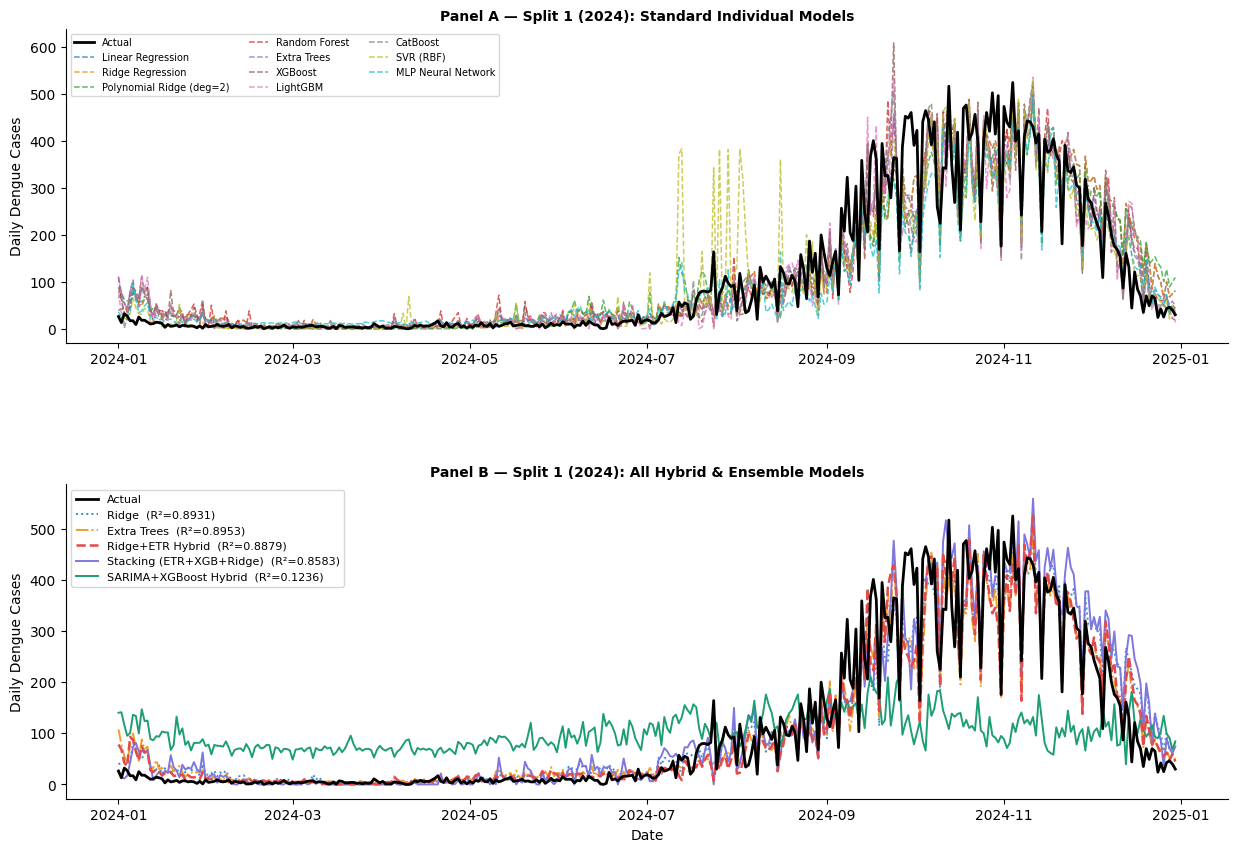

Saved: Robustness_Split1_Full.png / .pdf


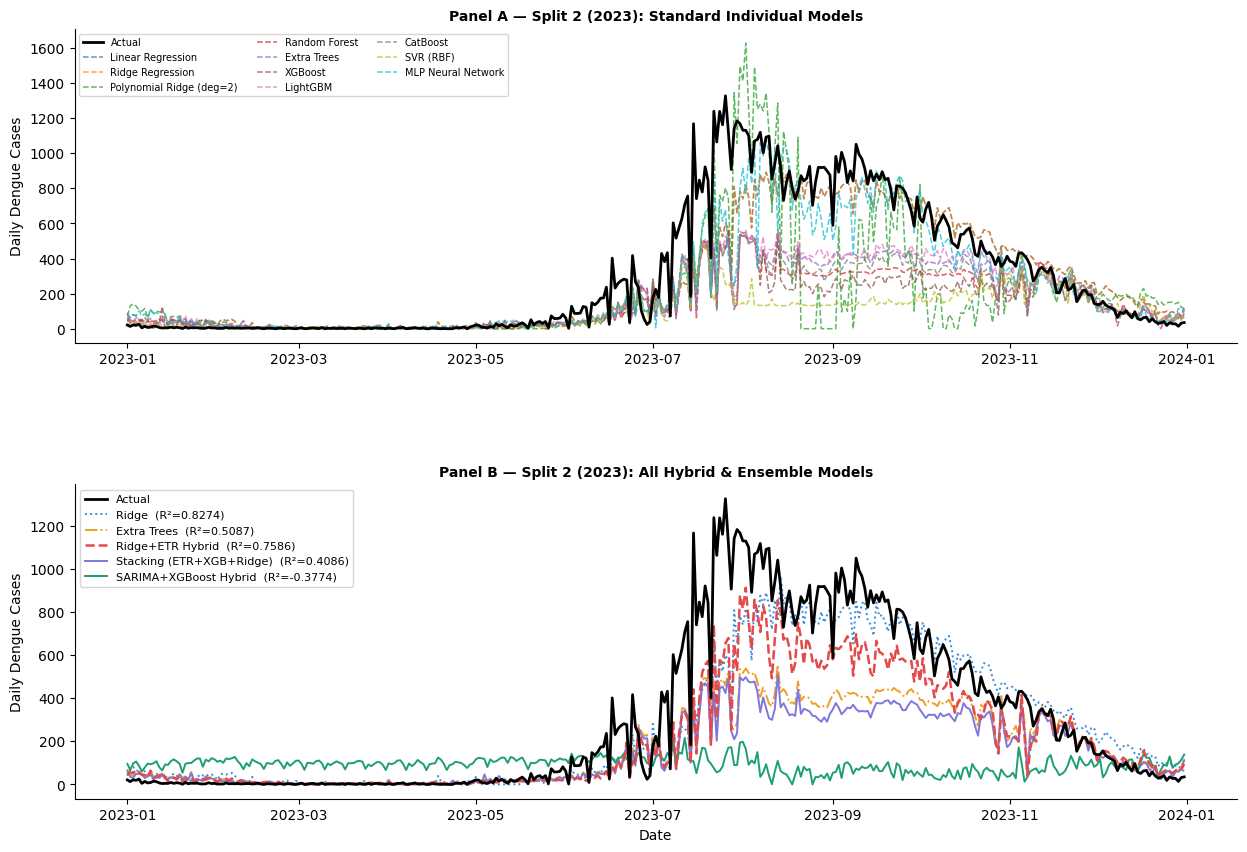

Saved: Robustness_Split2_Full.png / .pdf


In [ ]:
"""
=============================================================
ROBUSTNESS CHECK — ALL MODELS + RIDGE+ETR HYBRID
                 + STACKING ENSEMBLE (ETR+XGB+Ridge)
                 + SARIMA + XGBOOST RESIDUAL HYBRID

Split 1: Train 2020–2023 | Test 2024
Split 2: Train 2020–2022 | Test 2023
Split 3: 3-Fold TimeSeriesSplit CV

Models:
  1.  Linear Regression
  2.  Ridge Regression
  3.  Polynomial Ridge (deg=2)
  4.  Random Forest
  5.  Extra Trees
  6.  Ridge + ETR Hybrid         ← Stage 1: Ridge | Stage 2: ETR on residuals
  7.  Stacking (ETR+XGB+Ridge)   ← Meta-learner: Ridge
  8.  SARIMA + XGBoost Hybrid    ← Stage 1: SARIMA | Stage 2: XGBoost on residuals
  9.  XGBoost
  10. LightGBM
  11. CatBoost
  12. SVR (RBF)
  13. MLP Neural Network
=============================================================
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               StackingRegressor)
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.base import BaseEstimator, RegressorMixin

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


# ─────────────────────────────────────────────
# CUSTOM MODEL 1 — RIDGE + ETR HYBRID
# ─────────────────────────────────────────────
class RidgeETRHybrid(BaseEstimator, RegressorMixin):
    """
    Two-stage residual hybrid:
      Stage 1: Ridge Regression (linear patterns)
      Stage 2: Extra Trees on Ridge residuals (nonlinear corrections)
      Final  : Ridge_pred + ETR_residual_correction

    Consistent with Chakraborty et al. (2019) ARIMA-NNAR
    philosophy and Liu et al. (2025) recommendation.
    """
    def __init__(self, ridge_alpha=1.0, n_estimators=400,
                 max_depth=10, random_state=42):
        self.ridge_alpha  = ridge_alpha
        self.n_estimators = n_estimators
        self.max_depth    = max_depth
        self.random_state = random_state

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        # Stage 1: Ridge
        self.ridge_ = Ridge(alpha=self.ridge_alpha)
        self.ridge_.fit(X, y)
        ridge_train_pred = self.ridge_.predict(X)

        # Residuals Ridge could not explain
        residuals = y - ridge_train_pred

        # Stage 2: ETR on residuals
        X_aug = np.column_stack([X, ridge_train_pred])
        self.etr_ = ExtraTreesRegressor(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            random_state=self.random_state,
            n_jobs=-1
        )
        self.etr_.fit(X_aug, residuals)
        return self

    def predict(self, X):
        X = np.array(X)
        ridge_pred = self.ridge_.predict(X)
        X_aug      = np.column_stack([X, ridge_pred])
        etr_corr   = self.etr_.predict(X_aug)
        return np.clip(ridge_pred + etr_corr, 0, None)


# ─────────────────────────────────────────────
# CUSTOM MODEL 2 — SARIMA + XGBOOST HYBRID
# ─────────────────────────────────────────────
class SARIMAXGBHybrid(BaseEstimator, RegressorMixin):
    """
    Two-stage residual hybrid:
      Stage 1: SARIMA(0,0,2)(2,1,2)7 — linear seasonality & trend
      Stage 2: XGBoost on SARIMA residuals — nonlinear correction
      Final  : SARIMA_forecast + XGBoost_residual_correction

    Inspired by Liu et al. (2025) & Chakraborty et al. (2019).
    """
    def __init__(self, n_estimators=500, learning_rate=0.05,
                 max_depth=6, random_state=42):
        self.n_estimators  = n_estimators
        self.learning_rate = learning_rate
        self.max_depth     = max_depth
        self.random_state  = random_state

    def fit(self, X, y):
        from statsmodels.tsa.statespace.sarimax import SARIMAX

        X = np.array(X)
        y = np.array(y)

        # Stage 1: Fit SARIMA on dengue series
        self.sarima_ = SARIMAX(
            y,
            order=(0, 0, 2),
            seasonal_order=(2, 1, 2, 7),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        sarima_fitted = self.sarima_.fittedvalues
        residuals     = y - sarima_fitted

        # Stage 2: XGBoost on residuals
        X_aug = np.column_stack([X, sarima_fitted])
        self.xgb_ = XGBRegressor(
            n_estimators=self.n_estimators,
            learning_rate=self.learning_rate,
            max_depth=self.max_depth,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=self.random_state,
            verbosity=0
        )
        self.xgb_.fit(X_aug, residuals)

        self.last_residual_ = residuals[-1]
        return self

    def predict(self, X):
        X = np.array(X)
        n = len(X)

        # Stage 1: SARIMA forecast
        sarima_pred = np.clip(
            self.sarima_.forecast(steps=n), 0, None
        )

        # Stage 2: XGBoost residual correction
        X_aug    = np.column_stack([X, np.full(n, self.last_residual_)])
        xgb_corr = self.xgb_.predict(X_aug)

        return np.clip(sarima_pred + xgb_corr, 0, None)


# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

# ============================================================
# 2. FEATURE ENGINEERING
# ============================================================
df["Temperature_Lag60"] = df["Temperature"].shift(60)
df["Humidity_Lag30"]    = df["Humidity"].shift(30)
df["Rainfall_Lag45"]    = df["Rainfall_mm"].shift(45)
df["Dengue_Lag7"]       = df["Dengue_Cases"].shift(7)
df["Dengue_Lag14"]      = df["Dengue_Cases"].shift(14)
df["Dengue_Lag30"]      = df["Dengue_Cases"].shift(30)

FEATURES = [
    "Temperature_Lag60", "Humidity_Lag30", "Rainfall_Lag45",
    "Dengue_Lag7", "Dengue_Lag14", "Dengue_Lag30"
]
TARGET = "Dengue_Cases"
df_ml  = df.dropna(subset=FEATURES + [TARGET]).copy()
X      = df_ml[FEATURES]
y      = df_ml[TARGET]

# ============================================================
# 3. METRIC FUNCTION
# ============================================================
def evaluate_model(name, y_true, y_pred):
    y_pred   = np.clip(y_pred, 0, None)
    y_true_a = np.array(y_true, dtype=float)

    rmse  = np.sqrt(mean_squared_error(y_true_a, y_pred))
    mse   = mean_squared_error(y_true_a, y_pred)
    mae   = mean_absolute_error(y_true_a, y_pred)
    r2    = r2_score(y_true_a, y_pred)

    mask  = y_true_a != 0
    mape  = (np.mean(np.abs((y_true_a[mask] - y_pred[mask])
             / y_true_a[mask])) * 100 if mask.sum() else np.nan)

    denom = np.abs(y_true_a) + np.abs(y_pred)
    mask2 = denom != 0
    smape = (np.mean(200 * np.abs(y_pred[mask2] - y_true_a[mask2])
             / denom[mask2]) if mask2.sum() else np.nan)

    return {"Model": name, "RMSE": rmse, "MSE": mse,
            "MAE": mae, "MAPE (%)": mape,
            "SMAPE (%)": smape, "R2": r2}


# ============================================================
# 4. ALL MODELS
# ============================================================
def get_models():
    return {
        # ── Linear Models ─────────────────────────────────────
        "Linear Regression": LinearRegression(),

        "Ridge Regression": Ridge(alpha=1.0),

        "Polynomial Ridge (deg=2)": Pipeline([
            ("poly",   PolynomialFeatures(degree=2, include_bias=False)),
            ("scaler", StandardScaler()),
            ("ridge",  Ridge(alpha=1.0))
        ]),

        # ── Tree-Based Models ─────────────────────────────────
        "Random Forest": RandomForestRegressor(
            n_estimators=400, max_depth=8,
            random_state=42, n_jobs=-1
        ),

        "Extra Trees": ExtraTreesRegressor(
            n_estimators=400, max_depth=10,
            random_state=42, n_jobs=-1
        ),

        # ── Hybrid / Ensemble Models ──────────────────────────
        "Ridge + ETR Hybrid": RidgeETRHybrid(
            ridge_alpha=1.0,
            n_estimators=400,
            max_depth=10,
            random_state=42
        ),

        "Stacking (ETR+XGB+Ridge)": StackingRegressor(
            estimators=[
                ("etr",   ExtraTreesRegressor(
                              n_estimators=400, max_depth=10,
                              random_state=42, n_jobs=-1)),
                ("xgb",   XGBRegressor(
                              n_estimators=500, learning_rate=0.05,
                              max_depth=6, subsample=0.8,
                              colsample_bytree=0.8,
                              random_state=42, verbosity=0)),
                ("ridge", Ridge(alpha=1.0)),
            ],
            final_estimator=Ridge(alpha=1.0),
            cv=5,
            passthrough=False,
            n_jobs=-1
        ),

        "SARIMA + XGBoost Hybrid": SARIMAXGBHybrid(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            random_state=42
        ),

        # ── Gradient Boosting Models ──────────────────────────
        "XGBoost": XGBRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8,
            objective="reg:squarederror", random_state=42,
            verbosity=0
        ),

        "LightGBM": LGBMRegressor(
            n_estimators=500, learning_rate=0.05,
            max_depth=4, random_state=42, verbose=-1
        ),

        "CatBoost": CatBoostRegressor(
            iterations=500, learning_rate=0.05, depth=6,
            loss_function="RMSE", random_seed=42, verbose=0
        ),

        # ── Other Models ──────────────────────────────────────
        "SVR (RBF)": Pipeline([
            ("scaler", StandardScaler()),
            ("model",  SVR(kernel="rbf", C=100,
                           gamma="scale", epsilon=0.1))
        ]),

        "MLP Neural Network": Pipeline([
            ("scaler", StandardScaler()),
            ("model",  MLPRegressor(
                hidden_layer_sizes=(64, 32),
                max_iter=1500, random_state=42))
        ]),
    }


new_models = ["Ridge + ETR Hybrid", "Stacking (ETR+XGB+Ridge)",
              "SARIMA + XGBoost Hybrid"]


# ============================================================
# 5. SPLIT 1: Train 2020–2023 | Test 2024
# ============================================================
train_s1   = df_ml[df_ml.index < "2024-01-01"]
test_s1    = df_ml[df_ml.index >= "2024-01-01"]
X_train_s1 = train_s1[FEATURES]; y_train_s1 = train_s1[TARGET]
X_test_s1  = test_s1[FEATURES];  y_test_s1  = test_s1[TARGET]

results_s1 = []
preds_s1   = {}

print("=" * 70)
print("SPLIT 1: Train 2020–2023 | Test 2024")
print("=" * 70)

for name, model in get_models().items():
    print(f"  Fitting: {name}...")
    model.fit(X_train_s1, y_train_s1)
    y_pred         = np.clip(model.predict(X_test_s1), 0, None)
    preds_s1[name] = y_pred
    row            = evaluate_model(name, y_test_s1, y_pred)
    row["Split"]   = "Split 1: Train 2020-2023 / Test 2024"
    results_s1.append(row)
    marker = " ← NEW" if name in new_models else ""
    print(f"  {name:35s} | RMSE:{row['RMSE']:8.3f} | "
          f"R²:{row['R2']:.4f}{marker}")

df_s1 = pd.DataFrame(results_s1)


# ============================================================
# 6. SPLIT 2: Train 2020–2022 | Test 2023
# ============================================================
train_s2   = df_ml[df_ml.index < "2023-01-01"]
test_s2    = df_ml[(df_ml.index >= "2023-01-01") &
                   (df_ml.index < "2024-01-01")]
X_train_s2 = train_s2[FEATURES]; y_train_s2 = train_s2[TARGET]
X_test_s2  = test_s2[FEATURES];  y_test_s2  = test_s2[TARGET]

results_s2 = []
preds_s2   = {}

print("\n" + "=" * 70)
print("SPLIT 2: Train 2020–2022 | Test 2023")
print("=" * 70)

for name, model in get_models().items():
    print(f"  Fitting: {name}...")
    model.fit(X_train_s2, y_train_s2)
    y_pred         = np.clip(model.predict(X_test_s2), 0, None)
    preds_s2[name] = y_pred
    row            = evaluate_model(name, y_test_s2, y_pred)
    row["Split"]   = "Split 2: Train 2020-2022 / Test 2023"
    results_s2.append(row)
    marker = " ← NEW" if name in new_models else ""
    print(f"  {name:35s} | RMSE:{row['RMSE']:8.3f} | "
          f"R²:{row['R2']:.4f}{marker}")

df_s2 = pd.DataFrame(results_s2)


# ============================================================
# 7. SPLIT 3: 3-Fold TimeSeriesSplit CV
# ============================================================
tscv    = TimeSeriesSplit(n_splits=3)
cv_rows = []

print("\n" + "=" * 70)
print("SPLIT 3: 3-Fold TimeSeriesSplit CV")
print("=" * 70)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_tr = X.iloc[train_idx]; y_tr = y.iloc[train_idx]
    X_te = X.iloc[test_idx];  y_te = y.iloc[test_idx]

    print(f"\n  Fold {fold}: {X_te.index[0].date()} → "
          f"{X_te.index[-1].date()}")

    for name, model in get_models().items():
        print(f"    Fitting: {name}...")
        model.fit(X_tr, y_tr)
        y_pred       = np.clip(model.predict(X_te), 0, None)
        row          = evaluate_model(name, y_te, y_pred)
        row["Split"] = "Split 3: TimeSeriesSplit CV"
        row["Fold"]  = fold
        cv_rows.append(row)
        marker = " ← NEW" if name in new_models else ""
        print(f"    {name:35s} | RMSE:{row['RMSE']:8.3f} | "
              f"R²:{row['R2']:.4f}{marker}")

df_cv_detail = pd.DataFrame(cv_rows)
df_cv_avg    = (
    df_cv_detail
    .groupby("Model")[["RMSE", "MSE", "MAE",
                        "MAPE (%)", "SMAPE (%)", "R2"]]
    .mean().reset_index()
)
df_cv_avg["Split"] = "Split 3: TimeSeriesSplit CV Mean"


# ============================================================
# 8. COMBINED SUMMARY TABLE
# ============================================================
robustness_summary = pd.concat([df_s1, df_s2, df_cv_avg],
                                ignore_index=True)
robustness_summary = robustness_summary[
    ["Model", "Split", "RMSE", "MSE", "MAE",
     "MAPE (%)", "SMAPE (%)", "R2"]
].sort_values(["Split", "RMSE"])

print("\n" + "=" * 70)
print("FINAL ROBUSTNESS SUMMARY")
print("=" * 70)
print(robustness_summary.round(3).to_string(index=False))


# ============================================================
# 9. STABILITY SUMMARY — mean RMSE across all splits
# ============================================================
stability = (
    robustness_summary
    .groupby("Model")
    .agg(RMSE_Mean=("RMSE", "mean"),
         RMSE_Std=("RMSE",  "std"),
         R2_Mean=("R2",     "mean"),
         MAE_Mean=("MAE",   "mean"))
    .reset_index()
    .sort_values(["RMSE_Mean", "RMSE_Std"])
)

print("\n" + "=" * 70)
print("MODEL STABILITY SUMMARY (mean across all 3 splits)")
print("=" * 70)
print(stability.round(3).to_string(index=False))

for nm in new_models:
    rank = stability.reset_index(drop=True).index[
        stability.Model == nm].tolist()
    if rank:
        print(f"\n  {nm} ranks #{rank[0]+1} "
              f"out of {len(stability)} models by mean RMSE")


# ============================================================
# 10. SAVE FILES
# ============================================================
robustness_summary.to_csv("Robustness_All_Models_Full.csv", index=False)
stability.to_csv("Stability_All_Models_Full.csv", index=False)
df_cv_detail.to_csv("CV_Detail_All_Models_Full.csv", index=False)
print("\nSaved: Robustness_All_Models_Full.csv")
print("Saved: Stability_All_Models_Full.csv")
print("Saved: CV_Detail_All_Models_Full.csv")


# ============================================================
# 11. FIGURE — SPLIT 1: Actual vs Predicted (2 Panels only)
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0.45)

# Panel A — all standard models
ax1 = axes[0]
ax1.plot(y_test_s1.index, y_test_s1.values,
         color="black", lw=2, label="Actual", zorder=5)
for name, pred in preds_s1.items():
    if name not in new_models:
        ax1.plot(y_test_s1.index, pred, lw=1.1,
                 linestyle="--", label=name, alpha=0.75)
ax1.set_title("Panel A — Split 1 (2024): Standard Individual Models",
              fontsize=10, fontweight="bold")
ax1.set_ylabel("Daily Dengue Cases")
ax1.legend(fontsize=7, ncol=3, loc="upper left")
ax1.spines[["top", "right"]].set_visible(False)

# Panel B — all hybrid & ensemble models
ax2 = axes[1]
ax2.plot(y_test_s1.index, y_test_s1.values,
         color="black", lw=2, label="Actual", zorder=5)
ax2.plot(y_test_s1.index, preds_s1["Ridge Regression"],
         color="#378ADD", lw=1.4, linestyle=":",
         label=f"Ridge  "
               f"(R²={df_s1[df_s1.Model=='Ridge Regression']['R2'].values[0]:.4f})")
ax2.plot(y_test_s1.index, preds_s1["Extra Trees"],
         color="#EF9F27", lw=1.4, linestyle="-.",
         label=f"Extra Trees  "
               f"(R²={df_s1[df_s1.Model=='Extra Trees']['R2'].values[0]:.4f})")
ax2.plot(y_test_s1.index, preds_s1["Ridge + ETR Hybrid"],
         color="#E24B4A", lw=1.8, linestyle="--",
         label=f"Ridge+ETR Hybrid  "
               f"(R²={df_s1[df_s1.Model=='Ridge + ETR Hybrid']['R2'].values[0]:.4f})",
         zorder=4)
ax2.plot(y_test_s1.index, preds_s1["Stacking (ETR+XGB+Ridge)"],
         color="#7F77DD", lw=1.4, linestyle="-",
         label=f"Stacking (ETR+XGB+Ridge)  "
               f"(R²={df_s1[df_s1.Model=='Stacking (ETR+XGB+Ridge)']['R2'].values[0]:.4f})")
ax2.plot(y_test_s1.index, preds_s1["SARIMA + XGBoost Hybrid"],
         color="#1D9E75", lw=1.4, linestyle="-",
         label=f"SARIMA+XGBoost Hybrid  "
               f"(R²={df_s1[df_s1.Model=='SARIMA + XGBoost Hybrid']['R2'].values[0]:.4f})")
ax2.set_title("Panel B — Split 1 (2024): All Hybrid & Ensemble Models",
              fontsize=10, fontweight="bold")
ax2.set_ylabel("Daily Dengue Cases")
ax2.set_xlabel("Date")
ax2.legend(fontsize=8, loc="upper left")
ax2.spines[["top", "right"]].set_visible(False)

#fig.suptitle(
    #"Robustness Check — Split 1 (Train 2020–2023 | Test 2024)\n"
    #"All Models: Standard + Ridge+ETR Hybrid + Stacking + SARIMA+XGBoost Hybrid",
    #fontsize=12, fontweight="bold", y=1.01
#)

plt.savefig("Robustness_Split1_Full.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("Robustness_Split1_Full.pdf",
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: Robustness_Split1_Full.png / .pdf")


# ============================================================
# 12. FIGURE — SPLIT 2: Actual vs Predicted (2 Panels only)
# ============================================================
fig2, axes2 = plt.subplots(2, 1, figsize=(15, 10))
fig2.subplots_adjust(hspace=0.45)

ax3 = axes2[0]
ax3.plot(y_test_s2.index, y_test_s2.values,
         color="black", lw=2, label="Actual", zorder=5)
for name, pred in preds_s2.items():
    if name not in new_models:
        ax3.plot(y_test_s2.index, pred, lw=1.1,
                 linestyle="--", label=name, alpha=0.75)
ax3.set_title("Panel A — Split 2 (2023): Standard Individual Models",
              fontsize=10, fontweight="bold")
ax3.set_ylabel("Daily Dengue Cases")
ax3.legend(fontsize=7, ncol=3, loc="upper left")
ax3.spines[["top", "right"]].set_visible(False)

ax4 = axes2[1]
ax4.plot(y_test_s2.index, y_test_s2.values,
         color="black", lw=2, label="Actual", zorder=5)
ax4.plot(y_test_s2.index, preds_s2["Ridge Regression"],
         color="#378ADD", lw=1.4, linestyle=":",
         label=f"Ridge  "
               f"(R²={df_s2[df_s2.Model=='Ridge Regression']['R2'].values[0]:.4f})")
ax4.plot(y_test_s2.index, preds_s2["Extra Trees"],
         color="#EF9F27", lw=1.4, linestyle="-.",
         label=f"Extra Trees  "
               f"(R²={df_s2[df_s2.Model=='Extra Trees']['R2'].values[0]:.4f})")
ax4.plot(y_test_s2.index, preds_s2["Ridge + ETR Hybrid"],
         color="#E24B4A", lw=1.8, linestyle="--",
         label=f"Ridge+ETR Hybrid  "
               f"(R²={df_s2[df_s2.Model=='Ridge + ETR Hybrid']['R2'].values[0]:.4f})",
         zorder=4)
ax4.plot(y_test_s2.index, preds_s2["Stacking (ETR+XGB+Ridge)"],
         color="#7F77DD", lw=1.4, linestyle="-",
         label=f"Stacking (ETR+XGB+Ridge)  "
               f"(R²={df_s2[df_s2.Model=='Stacking (ETR+XGB+Ridge)']['R2'].values[0]:.4f})")
ax4.plot(y_test_s2.index, preds_s2["SARIMA + XGBoost Hybrid"],
         color="#1D9E75", lw=1.4, linestyle="-",
         label=f"SARIMA+XGBoost Hybrid  "
               f"(R²={df_s2[df_s2.Model=='SARIMA + XGBoost Hybrid']['R2'].values[0]:.4f})")
ax4.set_title("Panel B — Split 2 (2023): All Hybrid & Ensemble Models",
              fontsize=10, fontweight="bold")
ax4.set_ylabel("Daily Dengue Cases")
ax4.set_xlabel("Date")
ax4.legend(fontsize=8, loc="upper left")
ax4.spines[["top", "right"]].set_visible(False)

#fig2.suptitle(
    #"Robustness Check — Split 2 (Train 2020–2022 | Test 2023)\n"
    #"All Models: Standard + Ridge+ETR Hybrid + Stacking + SARIMA+XGBoost Hybrid",
    #fontsize=12, fontweight="bold", y=1.01
#)

plt.savefig("Robustness_Split2_Full.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("Robustness_Split2_Full.pdf",
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: Robustness_Split2_Full.png / .pdf")

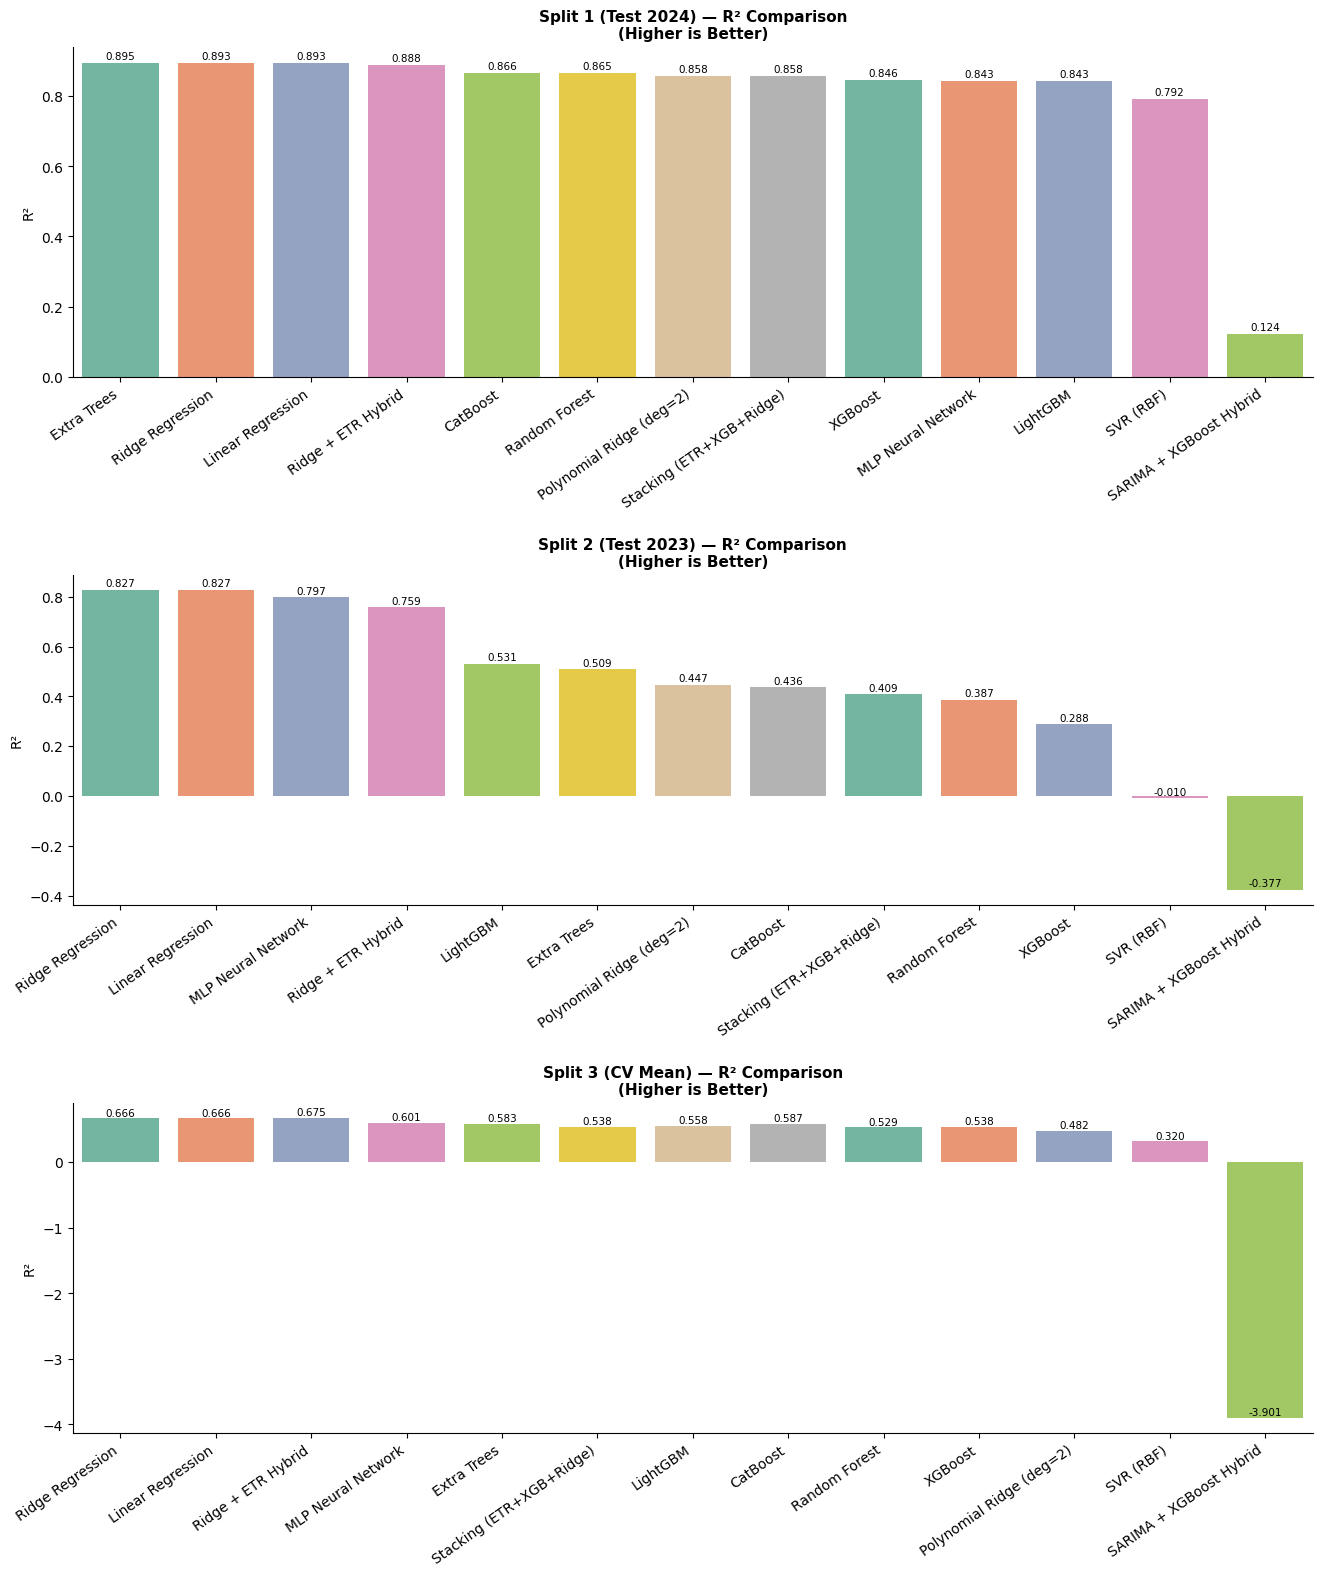

Saved: Model_R2_Per_Split.png / .pdf


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

splits = {
    "Split 1: Train 2020-2023 / Test 2024": "Split 1 (Test 2024)",
    "Split 2: Train 2020-2022 / Test 2023": "Split 2 (Test 2023)",
    "Split 3: TimeSeriesSplit CV Mean":      "Split 3 (CV Mean)",
}

fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.subplots_adjust(hspace=0.6)

for ax, (split_name, split_label) in zip(axes, splits.items()):
    data = robustness_summary[robustness_summary["Split"] == split_name]

    sns.barplot(
        data=data,
        x="Model", y="R2",
        palette="Set2", ax=ax
    )

    ax.set_title(f"{split_label} — R² Comparison\n(Higher is Better)",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("R²")
    ax.tick_params(axis="x", rotation=35)
    ax.set_xticklabels(ax.get_xticklabels(), ha="right")
    ax.spines[["top", "right"]].set_visible(False)

    # Add value labels on top of each bar
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=7.5
        )

#fig.suptitle("R² Comparison Across All Models — Split 1 vs Split 2 vs Split 3",
             #fontsize=13, fontweight="bold", y=1.01)

plt.savefig("Model_R2_Per_Split.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.savefig("Model_R2_Per_Split.pdf",
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: Model_R2_Per_Split.png / .pdf")